# P5 v2 Strict: 2024 Major7 Grade-Signal Heterogeneity

이 노트북은 P4 strict-clean/manual-approved 계약을 SSOT로 사용해 P5 major7 이질성 분석을 재실행한다.

- 기존 `p5_major7_heterogeneity_v1/` 산출물은 읽기 전용 비교 대상으로만 사용한다.
- 입력 D08 path, shape, SHA256은 P4 v4 active input audit와 readiness status에서 읽어 검증한다.
- 현재 실행 signal은 `RAW_A`만 사용한다. `WITHIN_MAJOR_A`는 계열별 절편 포함 모형에서 RAW_A와 slope가 동일하므로 계열별 slope 모형에서는 제거한다.
- P3 manifest가 제공될 때만 OOF residual branch를 추가한다. 현재 residual branch는 upstream 대기 상태로 처리한다.

In [1]:
# 셀 01 목적: 실행 환경과 출력 폴더를 고정한다.
# 입력: 현재 작업 디렉터리, P4 strict readiness 파일이 있는 repo tree.
# 처리: PROJECT_ROOT를 찾고, strict P5 산출물 폴더/하위 폴더를 생성한다.
# 출력: EXECUTION_CONTEXT. 이후 모든 셀의 경로 기준과 재현성 메타데이터가 된다.
# 해석 포인트: 이 셀은 모델 결과를 만들지 않고, "어느 checkout/환경에서 실행했는가"를 고정한다.

from __future__ import annotations

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patsy
import statsmodels.api as sm

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

warnings.filterwarnings("default")

RANDOM_STATE = 3085
MIN_ROWS = 100
MIN_SCHOOLS = 15
RARE_LEVEL_MIN_N = 10
KEY = "outcome_row_id"

def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for path in [cur, *cur.parents]:
        if (path / "workbook/p2/p2_4/p4_modeling_readiness_v4/qa/P4_V4_ACTIVE_INPUT_AUDIT.csv").exists():
            return path
    raise RuntimeError("repo root not found")

PROJECT_ROOT = find_project_root(Path.cwd())
V1_ROOT = PROJECT_ROOT / "workbook/p2/p2_5/p5_major7_heterogeneity_v1"
OUTPUT_ROOT = PROJECT_ROOT / "workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict"
NOTEBOOK_PATH = OUTPUT_ROOT / "p2_g5_1_strict.ipynb"
ARTIFACTS_DIR = OUTPUT_ROOT / "artifacts"
DATA_DIR = OUTPUT_ROOT / "data"
FIGURES_DIR = OUTPUT_ROOT / "figures"
QA_DIR = OUTPUT_ROOT / "qa"
REPORTS_DIR = OUTPUT_ROOT / "reports"
LOGS_DIR = OUTPUT_ROOT / "logs"

for path in [OUTPUT_ROOT, ARTIFACTS_DIR, DATA_DIR, FIGURES_DIR, QA_DIR, REPORTS_DIR, LOGS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

def sha256_file(path: Path) -> str:
    hasher = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def as_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.fillna(False)
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes", "y"})

def parse_shape(value):
    if isinstance(value, (list, tuple)):
        return tuple(value)
    if pd.isna(value):
        return None
    text = str(value).strip()
    try:
        loaded = json.loads(text)
        if isinstance(loaded, list):
            return tuple(loaded)
    except Exception:
        pass
    text = text.strip("[]()")
    parts = [p.strip() for p in text.split(",") if p.strip() and p.strip().lower() != "none"]
    if not parts:
        return None
    return tuple(int(float(p)) for p in parts)

def file_shape(path: Path):
    if path.suffix == ".parquet":
        return tuple(pd.read_parquet(path).shape)
    if path.suffix.lower() == ".csv":
        return tuple(pd.read_csv(path).shape)
    if path.suffix.lower() == ".json":
        payload = json.loads(path.read_text(encoding="utf-8"))
        if isinstance(payload, list):
            return (len(payload), None)
        if isinstance(payload, dict):
            return (len(payload), None)
    return None

def rel(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def git_commit() -> str:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True).strip()
    except Exception as exc:
        return f"UNAVAILABLE: {type(exc).__name__}"

EXECUTION_CONTEXT = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "statsmodels": sm.__version__,
    "working_directory": str(PROJECT_ROOT),
    "git_commit": git_commit(),
    "execution_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "notebook_path": str(NOTEBOOK_PATH),
    "output_root": str(OUTPUT_ROOT),
}
print(json.dumps(EXECUTION_CONTEXT, ensure_ascii=False, indent=2))

{
  "python": "3.12.3",
  "platform": "Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39",
  "pandas": "3.0.3",
  "numpy": "2.5.0",
  "statsmodels": "0.14.6",
  "working_directory": "/home/sieg/projects-wsl/SBS_dataScience",
  "git_commit": "5b1a3d54266d881a839ad9a3cec750da66e94bc7",
  "execution_timestamp_utc": "2026-07-13T06:09:50.971201+00:00",
  "notebook_path": "/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/p2_g5_1_strict.ipynb",
  "output_root": "/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict"
}


In [2]:
# 셀 02 목적: P4 strict-clean/manual-approved 입력 계약을 검증한다.
# 입력: P4_FINAL_MODELING_READINESS.json, P4_V4_ACTIVE_INPUT_AUDIT.csv, manual policy 검증표.
# 처리: strict D08 path/shape/SHA256, manual feature registry, strict target count를 P4 계약과 대조한다.
# 출력: qa/P5_STRICT_INPUT_CONTRACT.csv 및 P5_STRICT_INPUT_STATUS.
# 해석 포인트: 여기서 막히면 모델링 문제가 아니라 입력 SSOT 계약 불일치다.

P4_ROOT = PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4"
P4_STATUS_PATH = P4_ROOT / "reports/P4_FINAL_MODELING_READINESS.json"
P4_INPUT_AUDIT_PATH = P4_ROOT / "qa/P4_V4_ACTIVE_INPUT_AUDIT.csv"
P4_POLICY_VERIFY_PATH = P4_ROOT / "qa/P4_STRICT_MANUAL_POLICY_VERIFICATION.csv"

p4_status = json.loads(P4_STATUS_PATH.read_text(encoding="utf-8"))
p4_input_audit = pd.read_csv(P4_INPUT_AUDIT_PATH)
p4_policy_verify = pd.read_csv(P4_POLICY_VERIFY_PATH)

def input_record(label: str) -> dict:
    hit = p4_input_audit.loc[p4_input_audit["label"].eq(label)]
    if hit.empty:
        raise RuntimeError(f"P4 active input audit missing label: {label}")
    return hit.iloc[0].to_dict()

strict_d08_record = input_record("strict_mart_department_model_base_2024")
manual_feature_record = input_record("manual_approved_feature_registry")
manual_target_policy_record = input_record("manual_approved_target_and_scope_policy")
strict_target_membership_record = input_record("strict_target_sample_membership")
strict_target_counts_record = input_record("strict_target_sample_counts")

INPUTS = {
    "strict_d08": Path(strict_d08_record["path"]),
    "phase_sample_membership": P4_ROOT / "data/P4_PHASE_SAMPLE_MEMBERSHIP_FINAL.parquet",
    "phase_sample_registry": P4_ROOT / "artifacts/P4_PHASE_SAMPLE_REGISTRY_FINAL.csv",
    "column_registry": P4_ROOT / "artifacts/department_model_column_registry_v4.csv",
    "feature_contract": P4_ROOT / "artifacts/P4_PHASE_FEATURE_SET_FINAL.csv",
    "model_spec": P4_ROOT / "artifacts/P4_PHASE_MODEL_SPEC_FINAL.csv",
    "target_denylist": P4_ROOT / "qa/P4_TARGET_SPECIFIC_DENYLIST_FINAL.csv",
    "manual_feature_registry": Path(manual_feature_record["path"]),
    "manual_target_policy": Path(manual_target_policy_record["path"]),
    "strict_target_membership": Path(strict_target_membership_record["path"]),
    "strict_target_counts": Path(strict_target_counts_record["path"]),
}

expected_target_counts = {
    "a_rate_pct": 7592,
    "cd_rate_pct": 7592,
    "f_rate_pct": 7592,
    "graduate_school_progression_rate_pct": 5674,
    "health_employment_rate_pct": 5600,
    "selectivity_proxy_pct": 3119,
}

input_rows = []
blockers = []
for name, path in INPUTS.items():
    exists = path.exists()
    shape = file_shape(path) if exists else None
    sha = sha256_file(path) if exists else None
    input_rows.append(
        {
            "input_name": name,
            "path": rel(path),
            "exists": exists,
            "shape": shape,
            "sha256": sha,
        }
    )
    if not exists:
        blockers.append(f"missing input: {name}")

strict_shape = parse_shape(p4_status["active_d08_shape"])
if parse_shape(strict_d08_record["shape"]) != strict_shape:
    blockers.append("P4 active audit strict D08 shape disagrees with readiness status")
if strict_d08_record["sha256"] != p4_status["active_d08_sha256"]:
    blockers.append("P4 active audit strict D08 sha disagrees with readiness status")
if file_shape(INPUTS["strict_d08"]) != strict_shape:
    blockers.append(f"strict D08 shape mismatch: {file_shape(INPUTS['strict_d08'])} != {strict_shape}")
if sha256_file(INPUTS["strict_d08"]) != p4_status["active_d08_sha256"]:
    blockers.append("strict D08 sha mismatch vs P4 readiness status")

manual_features = pd.read_csv(INPUTS["manual_feature_registry"])
manual_true_n = int(as_bool(manual_features["manual_approved_p4_use"]).sum())
if tuple(manual_features.shape) != tuple(p4_status["manual_approved_feature_registry_shape"]):
    blockers.append("manual-approved feature registry shape mismatch")
if manual_true_n != int(p4_status["manual_approved_p4_use_true_n"]):
    blockers.append("manual-approved feature true count mismatch")

target_counts = pd.read_csv(INPUTS["strict_target_counts"])
count_map = target_counts.set_index("target_candidate")["strict_target_keep_n"].to_dict()
for target, expected_n in expected_target_counts.items():
    actual_n = int(count_map.get(target, -1))
    if actual_n != expected_n:
        blockers.append(f"strict target sample count mismatch: {target}={actual_n}, expected={expected_n}")

failed_policy = p4_policy_verify.loc[~p4_policy_verify["status"].isin(["PASS", "INFO"])]
if not failed_policy.empty:
    blockers.append("P4 strict/manual policy verification has failed rows")

df_input_contract = pd.DataFrame(input_rows)
display(df_input_contract)
display(p4_policy_verify)
df_input_contract.to_csv(QA_DIR / "P5_STRICT_INPUT_CONTRACT.csv", index=False)
p4_policy_verify.to_csv(QA_DIR / "P5_P4_STRICT_MANUAL_POLICY_VERIFICATION_COPY.csv", index=False)

if blockers:
    raise RuntimeError("P5_STRICT_INPUT_STATUS=BLOCKED_INPUT: " + "; ".join(blockers))

P5_STRICT_INPUT_STATUS = "READY"
print("P5_STRICT_INPUT_STATUS =", P5_STRICT_INPUT_STATUS)

,input_name,path,exists,shape,sha256
0,strict_d08,workbook/p2/p2_4/source_eda/strict_clean_v1/ma...,True,"(7592, 151)",5f56e375fd1c0474a5e55652859ae007e2f45becd6d335...
1,phase_sample_membership,workbook/p2/p2_4/p4_modeling_readiness_v4/data...,True,"(7592, 21)",c6504fd04c918ce33439462f7b277aa8ae4363f185ef93...
2,phase_sample_registry,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(12, 12)",d518bab363399a31037590a2cb285f2a76e88318f5d25b...
3,column_registry,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(151, 27)",c8f3954654de2853c92c4643b7ccf5cb271a7ad50de925...
4,feature_contract,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(241, 11)",05e3d5a89e4405d305ee496efc6dae97c1a790c2023c88...
5,model_spec,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(18, 11)",7887229f14c99f2fc729724944e2c174824770bd3c8fd1...
6,target_denylist,workbook/p2/p2_4/p4_modeling_readiness_v4/qa/P...,True,"(16, 3)",97435cb3a6b20b490ce2ce7e65160414517aee5b472f8e...
7,manual_feature_registry,workbook/p2/p2_4/source_eda/human_handoff_pack...,True,"(198, 11)",2cdb7797c4619c625fc6a171710970b7691446f4d62cae...
8,manual_target_policy,workbook/p2/p2_4/source_eda/human_handoff_pack...,True,"(32, 7)",c3f56647cc63135dd74609ed4b0436d0058655fc0e8235...
9,strict_target_membership,workbook/p2/p2_4/source_eda/strict_clean_v1/st...,True,"(61452, 7)",29bf19120774e7d0a86e1c6b6892d012832f3fd6fd5dbe...


,check,actual,expected,status,path
0,strict_d08_shape,"[7592, 151]","[7592, 151]",PASS,NaN
1,manual_approved_p4_use_true_n,131,131,PASS,NaN
2,strict_target_sample_count__a_rate_pct,7592,7592,PASS,NaN
3,strict_target_sample_count__cd_rate_pct,7592,7592,PASS,NaN
4,strict_target_sample_count__f_rate_pct,7592,7592,PASS,NaN
5,strict_target_sample_count__graduate_school_pr...,5674,5674,PASS,NaN
6,strict_target_sample_count__health_employment_...,5600,5600,PASS,NaN
7,strict_target_sample_count__selectivity_proxy_pct,3119,3119,PASS,NaN
8,manual_target_scope_policy_rows,32,32,PASS,NaN
9,human_required_decision_sheet_approved,13,13,PASS,workbook/p2/p2_4/source_eda/strict_clean_v1/hu...


P5_STRICT_INPUT_STATUS = READY


In [3]:
# 셀 03 목적: strict D08과 P4 membership을 조인해 P5 분석 표본을 만든다.
# 입력: strict_d08 parquet, P4 phase sample membership/registry.
# 처리: outcome_row_id one-to-one 조인, structure/selectivity sample flag 필터링.
# 출력: df_p5_structure(N=5600), df_p5_selectivity(N=2355), qa/P5_STRICT_SAMPLE_AUDIT.csv.
# 해석 포인트: 이후 slope는 전체 대학 데이터가 아니라 이 strict sample gate를 통과한 관측치에 대한 결과다.

df_d08 = pd.read_parquet(INPUTS["strict_d08"])
df_membership = pd.read_parquet(INPUTS["phase_sample_membership"])
df_sample_registry = pd.read_csv(INPUTS["phase_sample_registry"])
df_column_registry = pd.read_csv(INPUTS["column_registry"])
df_feature_contract = pd.read_csv(INPUTS["feature_contract"])
df_model_spec = pd.read_csv(INPUTS["model_spec"])
df_target_denylist = pd.read_csv(INPUTS["target_denylist"])
df_strict_target_membership = pd.read_csv(INPUTS["strict_target_membership"])

if not df_d08[KEY].is_unique:
    raise RuntimeError("P5_STRICT_INPUT_STATUS=BLOCKED_SAMPLE: strict D08 key not unique")
if not df_membership[KEY].is_unique:
    raise RuntimeError("P5_STRICT_INPUT_STATUS=BLOCKED_SAMPLE: P4 membership key not unique")

df_base = df_d08.merge(df_membership, on=KEY, how="left", validate="one_to_one", suffixes=("", "_membership"))
sample_flags = [c for c in df_base.columns if c.startswith("sample_")]
if df_base[sample_flags].isna().all(axis=1).any():
    raise RuntimeError("P5_STRICT_INPUT_STATUS=BLOCKED_SAMPLE: missing P4 membership rows")

def build_sample(sample_id: str) -> pd.DataFrame:
    flag = f"sample_{sample_id}"
    if flag not in df_base.columns:
        raise KeyError(flag)
    out = df_base.loc[as_bool(df_base[flag])].copy()
    out["p5_sample_id"] = sample_id
    return out

df_p5_structure = build_sample("P4_JOINT_STRUCTURE_READY")
df_p5_selectivity = build_sample("P4_JOINT_SELECTIVITY_READY")

def registry_row(sample_id: str) -> dict:
    hit = df_sample_registry.loc[df_sample_registry["sample_id"].eq(sample_id)]
    if hit.empty:
        raise RuntimeError(f"sample registry missing {sample_id}")
    return hit.iloc[0].to_dict()

structure_registry = registry_row("P4_JOINT_STRUCTURE_READY")
selectivity_registry = registry_row("P4_JOINT_SELECTIVITY_READY")

structure_audit = {
    "sample_id": "P4_JOINT_STRUCTURE_READY",
    "row_n": len(df_p5_structure),
    "expected_row_n": int(structure_registry["row_n"]),
    "school_n": int(df_p5_structure["school_uid"].nunique()),
    "expected_school_n": int(structure_registry["school_n"]),
    "split": df_p5_structure["split"].value_counts(dropna=False).to_dict(),
}
selectivity_audit = {
    "sample_id": "P4_JOINT_SELECTIVITY_READY",
    "row_n": len(df_p5_selectivity),
    "expected_row_n": int(selectivity_registry["row_n"]),
    "school_n": int(df_p5_selectivity["school_uid"].nunique()),
    "expected_school_n": int(selectivity_registry["school_n"]),
    "split": df_p5_selectivity["split"].value_counts(dropna=False).to_dict(),
}

if structure_audit["row_n"] != 5600 or structure_audit["row_n"] != structure_audit["expected_row_n"]:
    raise RuntimeError(f"P5_STRICT_STRUCTURE_STATUS=BLOCKED_SAMPLE: {structure_audit}")
if selectivity_audit["row_n"] != 2355 or selectivity_audit["row_n"] != selectivity_audit["expected_row_n"]:
    raise RuntimeError(f"P5_STRICT_SELECTIVITY_STATUS=BLOCKED_SAMPLE: {selectivity_audit}")

df_sample_audit = pd.DataFrame([structure_audit, selectivity_audit])
display(df_sample_audit)
df_sample_audit.to_csv(QA_DIR / "P5_STRICT_SAMPLE_AUDIT.csv", index=False)

P5_STRICT_STRUCTURE_STATUS = "READY"
P5_STRICT_SELECTIVITY_STATUS = "READY"

,sample_id,row_n,expected_row_n,school_n,expected_school_n,split
0,P4_JOINT_STRUCTURE_READY,5600,5600,185,185,"{'train': 4080, 'val': 871, 'test': 649}"
1,P4_JOINT_SELECTIVITY_READY,2355,2355,130,130,"{'train': 1742, 'val': 360, 'test': 253}"


In [4]:
# 셀 04 목적: outcome, control set, grade signal을 정의하고 RAW_A 모델 입력 신호를 파생한다.
# 입력: df_p5_structure, df_p5_selectivity, P3 manifest 후보.
# 처리: pct outcome을 prop outcome으로 변환하고 RAW_A=a_rate_pct/10을 만든다.
# 출력: P5_STRICT_SIGNAL_DERIVATION_AUDIT.csv, P5_RESIDUAL_STATUS.
# 해석 포인트: WITHIN_MAJOR_A는 strict 계열별 slope에서 중복 branch라 제거하고 RAW_A만 해석한다.

OUTCOME_SPECS = {
    "HEALTH_EMPLOYMENT": {
        "pct": "health_employment_rate_pct",
        "prop": "health_employment_rate_prop",
        "label": "건강보험 취업률",
    },
    "GRAD_SCHOOL_PROGRESSION": {
        "pct": "graduate_school_progression_rate_pct",
        "prop": "graduate_school_progression_rate_prop",
        "label": "대학원 진학률",
    },
}
COMMON_CATEGORICAL = ["school_type", "region_sido", "campus_branch", "credit_forfeit_flag"]
B_CORE = [
    "female_student_share_pct",
    "international_student_share_pct",
    "leave_rate_pct",
    "student_faculty_ratio",
    "fulltime_faculty_share_pct",
]
B_SCALE = ["log_enrolled_students", "log_graduates"]
Q_PRIMARY = ["selectivity_proxy_pct", "competition_ratio"]
CONTROL_SETS = [
    {
        "branch": "STRUCTURE",
        "control_set": "B_CORE",
        "sample_id": "P4_JOINT_STRUCTURE_READY",
        "frame_name": "df_p5_structure",
        "categorical": COMMON_CATEGORICAL,
        "numeric": B_CORE,
        "primary": True,
    },
    {
        "branch": "STRUCTURE",
        "control_set": "B_CORE_B_SCALE",
        "sample_id": "P4_JOINT_STRUCTURE_READY",
        "frame_name": "df_p5_structure",
        "categorical": COMMON_CATEGORICAL,
        "numeric": B_CORE + B_SCALE,
        "primary": False,
    },
    {
        "branch": "SELECTIVITY",
        "control_set": "B_CORE_B_SCALE_Q",
        "sample_id": "P4_JOINT_SELECTIVITY_READY",
        "frame_name": "df_p5_selectivity",
        "categorical": COMMON_CATEGORICAL,
        "numeric": B_CORE + B_SCALE + Q_PRIMARY,
        "primary": True,
    },
]
GRADE_SIGNALS = {
    "RAW_A": {
        "column": "a_rate_10pp",
        "source_column": "a_rate_pct",
        "label": "Raw A rate, 10pp",
    }
}

p3_manifest_candidates = sorted(PROJECT_ROOT.rglob("P3_OUTPUT_MANIFEST.json"))
if p3_manifest_candidates:
    P5_RESIDUAL_STATUS = "READY_MANIFEST_FOUND_NOT_MERGED"
    P5_RESIDUAL_NOTE = f"Manifest found at {rel(p3_manifest_candidates[0])}; OOF parser is intentionally manifest-gated."
else:
    P5_RESIDUAL_STATUS = "PENDING_UPSTREAM_RESIDUAL"
    P5_RESIDUAL_NOTE = "No P3_OUTPUT_MANIFEST.json found. OOF residual branch was not run."

df_residual_gate = pd.DataFrame([{"status": P5_RESIDUAL_STATUS, "note": P5_RESIDUAL_NOTE}])
display(df_residual_gate)
df_residual_gate.to_csv(QA_DIR / "P5_P3_RESIDUAL_GATE.csv", index=False)

def derive_signals(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["health_employment_rate_prop"] = pd.to_numeric(out["health_employment_rate_pct"], errors="coerce") / 100
    out["graduate_school_progression_rate_prop"] = pd.to_numeric(out["graduate_school_progression_rate_pct"], errors="coerce") / 100
    a_rate_float64 = pd.to_numeric(out["a_rate_pct"], errors="coerce").astype("float64")
    out["a_rate_10pp"] = a_rate_float64 / 10
    out["a_rate_major_year_mean"] = (
        a_rate_float64.groupby([out["major_group_7"], out["analysis_year"]]).transform("mean")
    )
    out["a_rate_within_major_year_pp"] = a_rate_float64 - out["a_rate_major_year_mean"]
    out["a_rate_within_major_year_10pp"] = out["a_rate_within_major_year_pp"] / 10
    return out

df_p5_structure = derive_signals(df_p5_structure)
df_p5_selectivity = derive_signals(df_p5_selectivity)

valid_major_values = sorted([x for x in df_d08["major_group_7"].dropna().unique().tolist()])
if len(valid_major_values) != 7:
    raise RuntimeError(f"P5_CONTEXT_STATUS=BLOCKED_MAJOR7: expected 7 valid majors, got {valid_major_values}")

signal_audit_rows = []
for name, frame in [("structure", df_p5_structure), ("selectivity", df_p5_selectivity)]:
    for outcome in OUTCOME_SPECS.values():
        prop = frame[outcome["prop"]]
        pct = frame[outcome["pct"]]
        signal_audit_rows.append({"frame": name, "column": outcome["pct"], "min": pct.min(), "max": pct.max(), "ok": bool(pct.dropna().between(0, 100).all())})
        signal_audit_rows.append({"frame": name, "column": outcome["prop"], "min": prop.min(), "max": prop.max(), "ok": bool(prop.dropna().between(0, 1).all())})
    within_mean = frame.groupby(["major_group_7", "analysis_year"])["a_rate_within_major_year_pp"].mean()
    signal_audit_rows.append({"frame": name, "column": "a_rate_within_major_year_pp", "min": within_mean.min(), "max": within_mean.max(), "ok": bool((within_mean.abs() < 1e-10).all())})

df_signal_audit = pd.DataFrame(signal_audit_rows)
display(df_signal_audit)
df_signal_audit.to_csv(QA_DIR / "P5_STRICT_SIGNAL_DERIVATION_AUDIT.csv", index=False)
if not df_signal_audit["ok"].all():
    raise RuntimeError("P5_RAW_A_STATUS=BLOCKED_SIGNAL_DERIVATION")

,status,note
0,PENDING_UPSTREAM_RESIDUAL,No P3_OUTPUT_MANIFEST.json found. OOF residual...


,frame,column,min,max,ok
0,structure,health_employment_rate_pct,0.000000e+00,1.000000e+02,True
1,structure,health_employment_rate_prop,0.000000e+00,1.000000e+00,True
2,structure,graduate_school_progression_rate_pct,0.000000e+00,9.285714e+01,True
3,structure,graduate_school_progression_rate_prop,0.000000e+00,9.285714e-01,True
4,structure,a_rate_within_major_year_pp,-3.063536e-15,2.980857e-15,True
5,selectivity,health_employment_rate_pct,0.000000e+00,1.000000e+02,True
6,selectivity,health_employment_rate_prop,0.000000e+00,1.000000e+00,True
7,selectivity,graduate_school_progression_rate_pct,0.000000e+00,7.209303e+01,True
8,selectivity,graduate_school_progression_rate_prop,0.000000e+00,7.209303e-01,True
9,selectivity,a_rate_within_major_year_pp,-2.524483e-15,3.182475e-15,True


In [5]:
# 셀 05 목적: 모델 적합에 필요한 공통 함수들을 정의한다.
# 입력: pandas DataFrame과 control column 목록.
# 처리: 희소 범주 collapse, patsy design matrix 생성, fractional logit/OLS cluster fit, AME 계산.
# 출력: 함수 묶음. 이 셀 자체는 모델을 fit하지 않는다.
# 해석 포인트: AME는 RAW_A +10%p 변화에 대한 outcome 평균 변화이며, 계수 beta와 같은 단위가 아니다.

def collapse_rare(series: pd.Series, min_n: int = RARE_LEVEL_MIN_N) -> pd.Series:
    safe = series.astype("string").fillna("__MISSING__")
    counts = safe.value_counts(dropna=False)
    rare = set(counts[counts < min_n].index)
    return safe.where(~safe.isin(rare), "__RARE__").astype(str)

def prepare_model_frame(df, outcome_prop, outcome_pct, signal_col, categorical, numeric):
    required = [KEY, "school_uid", "major_group_7", outcome_prop, outcome_pct, signal_col] + list(categorical) + list(numeric)
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"missing model columns: {missing}")
    model_df = df.loc[:, list(dict.fromkeys(required))].copy()
    for col in [outcome_prop, outcome_pct, signal_col] + list(numeric):
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    model_df = model_df.dropna(subset=[outcome_prop, outcome_pct, signal_col, "school_uid"]).copy()
    model_df = model_df[(model_df[outcome_prop] >= 0) & (model_df[outcome_prop] <= 1)].copy()
    return model_df

def design_matrix(model_df, outcome_col, signal_col, categorical, numeric):
    design_df = model_df.copy()
    active_cat = []
    active_num = []
    rare_warnings = []
    for col in categorical:
        counts = design_df[col].astype("string").fillna("__MISSING__").value_counts(dropna=False)
        rare_count = int((counts < RARE_LEVEL_MIN_N).sum())
        if rare_count:
            rare_warnings.append(f"{col}: rare_levels={rare_count}")
        design_df[col] = collapse_rare(design_df[col])
        if design_df[col].nunique(dropna=False) >= 2:
            active_cat.append(col)
    for col in numeric:
        design_df[col] = pd.to_numeric(design_df[col], errors="coerce")
        if design_df[col].notna().sum() >= MIN_ROWS and design_df[col].nunique(dropna=True) >= 2:
            active_num.append(col)
    design_df = design_df.dropna(subset=[outcome_col, signal_col, "school_uid"] + active_num).copy()
    terms = [signal_col] + [f"C({c})" for c in active_cat] + active_num
    formula = f"{outcome_col} ~ " + " + ".join(terms)
    y_m, X_m = patsy.dmatrices(formula, data=design_df, return_type="matrix")
    y = pd.Series(np.asarray(y_m).ravel(), index=design_df.index, name=outcome_col)
    X = pd.DataFrame(np.asarray(X_m), columns=X_m.design_info.column_names, index=design_df.index)
    keep_cols = ["Intercept"] + [c for c in X.columns if c != "Intercept" and X[c].nunique(dropna=False) >= 2]
    X = X.loc[:, [c for c in keep_cols if c in X.columns]].astype(float)
    rank = int(np.linalg.matrix_rank(X.to_numpy())) if len(X) and X.shape[1] else 0
    return {
        "design_df": design_df,
        "y": y,
        "X": X,
        "design_info": X_m.design_info,
        "formula": formula,
        "rank": rank,
        "rank_full": bool(rank == X.shape[1]),
        "rare_warnings": rare_warnings,
        "active_categorical": active_cat,
        "active_numeric": active_num,
    }

def fit_glm(y, X, groups):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = sm.GLM(y, X, family=sm.families.Binomial()).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups},
            maxiter=100,
            disp=0,
        )
    return result, [str(w.message) for w in caught]

def fit_ols(y, X, groups):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": groups})
    return result, [str(w.message) for w in caught]

def ame_10pp(result, design_info, design_df, signal_col, columns=None, params=None):
    params = result.params if params is None else params
    base = design_df.copy()
    shifted = design_df.copy()
    shifted[signal_col] = shifted[signal_col] + 1.0
    X0 = patsy.build_design_matrices([design_info], base, return_type="dataframe")[0]
    X1 = patsy.build_design_matrices([design_info], shifted, return_type="dataframe")[0]
    if columns is not None:
        X0 = X0.reindex(columns=columns, fill_value=0).astype(float)
        X1 = X1.reindex(columns=columns, fill_value=0).astype(float)
    p0 = result.model.predict(params, exog=X0)
    p1 = result.model.predict(params, exog=X1)
    return float(np.nanmean(p1 - p0))

def ame_ci_signal(result, design_info, design_df, signal_col, columns):
    if signal_col not in result.params.index:
        return np.nan, np.nan
    se = result.bse.get(signal_col, np.nan)
    if pd.isna(se):
        return np.nan, np.nan
    lo_params = result.params.copy()
    hi_params = result.params.copy()
    lo_params[signal_col] = lo_params[signal_col] - 1.96 * se
    hi_params[signal_col] = hi_params[signal_col] + 1.96 * se
    lo = ame_10pp(result, design_info, design_df, signal_col, columns, lo_params)
    hi = ame_10pp(result, design_info, design_df, signal_col, columns, hi_params)
    return min(lo, hi), max(lo, hi)

def eligibility(frame, branch, major, outcome_key, outcome_spec, signal_name, signal_spec):
    sub = frame.loc[frame["major_group_7"].eq(major)].copy()
    y = pd.to_numeric(sub[outcome_spec["prop"]], errors="coerce")
    sig = pd.to_numeric(sub[signal_spec["column"]], errors="coerce")
    nonnull = sub.loc[y.notna() & sig.notna()].copy()
    y2 = pd.to_numeric(nonnull[outcome_spec["prop"]], errors="coerce")
    s2 = pd.to_numeric(nonnull[signal_spec["column"]], errors="coerce")
    row_n = len(nonnull)
    school_n = int(nonnull["school_uid"].nunique())
    blockers = []
    warns = []
    outcome_non_null_n = int(y.notna().sum())
    signal_nunique = int(s2.nunique(dropna=True))
    signal_std = float(s2.std(ddof=1)) if len(s2) > 1 else np.nan
    outcome_std = float(y2.std(ddof=1)) if len(y2) > 1 else np.nan
    zero_ratio = float((y2 == 0).mean()) if len(y2) else np.nan
    if row_n < MIN_ROWS:
        blockers.append("row_n < 100")
    if school_n < MIN_SCHOOLS:
        blockers.append("school_n < 15")
    if outcome_non_null_n < MIN_ROWS:
        blockers.append("outcome non-null_n < 100")
    if signal_nunique < 10:
        blockers.append("Grade Signal nunique < 10")
    if not pd.notna(signal_std) or signal_std <= 0:
        blockers.append("Grade Signal std <= 0")
    if not pd.notna(outcome_std) or outcome_std <= 0:
        blockers.append("outcome std <= 0")
    if row_n < 200:
        warns.append("row_n < 200")
    if school_n < 25:
        warns.append("school_n < 25")
    if pd.notna(zero_ratio) and zero_ratio > 0.60:
        warns.append("outcome zero_ratio > 0.60")
    return {
        "branch": branch,
        "major_group_7": major,
        "outcome": outcome_key,
        "grade_signal": signal_name,
        "row_n": row_n,
        "school_n": school_n,
        "outcome_non_null_n": outcome_non_null_n,
        "outcome_zero_ratio": zero_ratio,
        "signal_nunique": signal_nunique,
        "signal_std": signal_std,
        "outcome_std": outcome_std,
        "estimable": not blockers,
        "blocker": " | ".join(blockers),
        "warning": " | ".join(warns),
    }

def result_row(result, model_family, cfg, major, outcome_key, outcome_spec, signal_name, signal_spec, design, row_n, school_n, status, warn):
    signal_col = signal_spec["column"]
    beta = result.params.get(signal_col, np.nan) if result is not None else np.nan
    se = result.bse.get(signal_col, np.nan) if result is not None else np.nan
    ci_low = ci_high = np.nan
    if result is not None and signal_col in result.params.index:
        try:
            ci = result.conf_int().loc[signal_col]
            ci_low, ci_high = float(ci.iloc[0]), float(ci.iloc[1])
        except Exception:
            pass
    glm_ame = glm_low = glm_high = np.nan
    if model_family == "fractional_logit" and result is not None and signal_col in result.params.index:
        glm_ame = ame_10pp(result, design["design_info"], design["design_df"], signal_col, design["X"].columns)
        glm_low, glm_high = ame_ci_signal(result, design["design_info"], design["design_df"], signal_col, design["X"].columns)
    return {
        "branch": cfg["branch"],
        "control_set": cfg["control_set"],
        "sample_id": cfg["sample_id"],
        "primary_model": bool(cfg["primary"]),
        "major_group_7": major,
        "outcome": outcome_key,
        "outcome_prop": outcome_spec["prop"],
        "outcome_pct": outcome_spec["pct"],
        "grade_signal": signal_name,
        "grade_signal_column": signal_col,
        "model_family": model_family,
        "beta": float(beta) if pd.notna(beta) else np.nan,
        "se": float(se) if pd.notna(se) else np.nan,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "odds_ratio_10pp": float(np.exp(beta)) if model_family == "fractional_logit" and pd.notna(beta) else np.nan,
        "ame_10pp": glm_ame,
        "ame_ci_low_10pp": glm_low,
        "ame_ci_high_10pp": glm_high,
        "ols_pp_10pp": float(beta) if model_family == "ols_cluster" and pd.notna(beta) else np.nan,
        "row_n": int(row_n),
        "school_n": int(school_n),
        "rank": int(design["rank"]),
        "rank_full": bool(design["rank_full"]),
        "converged": bool(getattr(result, "converged", True)) if result is not None else False,
        "status": status,
        "model_warning": " | ".join(dict.fromkeys(warn))[:2000],
        "formula": design["formula"],
    }

In [6]:
# 셀 06 목적: major7 × outcome × branch별 모델 cell을 실제로 적합한다.
# 입력: CONTROL_SETS, OUTCOME_SPECS, GRADE_SIGNALS, df_p5_structure/selectivity.
# 처리: eligibility 검사 후 fractional_logit과 OLS cluster를 각각 적합한다.
# 출력: P5_MAJOR7_SLOPE_ESTIMATES.csv, P5_CELL_ELIGIBILITY.csv, P5_MODEL_SPEC_REGISTRY.csv.
# 해석 포인트: 핵심 모델 결과는 fractional_logit primary STRUCTURE/B_CORE의 ame_10pp다.

frame_map = {"df_p5_structure": df_p5_structure, "df_p5_selectivity": df_p5_selectivity}
eligibility_rows = []
model_rows = []
model_grid_rows = []
failure_rows = []

for cfg in CONTROL_SETS:
    frame = frame_map[cfg["frame_name"]]
    for major in valid_major_values:
        for outcome_key, outcome_spec in OUTCOME_SPECS.items():
            for signal_name, signal_spec in GRADE_SIGNALS.items():
                elig = eligibility(frame, cfg["branch"], major, outcome_key, outcome_spec, signal_name, signal_spec)
                eligibility_rows.append(elig)
                model_grid_rows.append(
                    {
                        "branch": cfg["branch"],
                        "control_set": cfg["control_set"],
                        "sample_id": cfg["sample_id"],
                        "major_group_7": major,
                        "outcome": outcome_key,
                        "grade_signal": signal_name,
                        "estimable": elig["estimable"],
                    }
                )
                if not elig["estimable"]:
                    continue
                sub = frame.loc[frame["major_group_7"].eq(major)].copy()
                try:
                    model_df = prepare_model_frame(
                        sub,
                        outcome_spec["prop"],
                        outcome_spec["pct"],
                        signal_spec["column"],
                        cfg["categorical"],
                        cfg["numeric"],
                    )
                    design = design_matrix(
                        model_df,
                        outcome_spec["prop"],
                        signal_spec["column"],
                        cfg["categorical"],
                        cfg["numeric"],
                    )
                    row_n = len(design["design_df"])
                    school_n = int(design["design_df"]["school_uid"].nunique())
                    status = "OK" if design["rank_full"] else "WARN_RANK_DEFICIENT"
                    groups = design["design_df"]["school_uid"]

                    glm_result, glm_warn = fit_glm(design["y"], design["X"], groups)
                    if not bool(getattr(glm_result, "converged", True)):
                        status_glm = "WARN_NOT_CONVERGED"
                    else:
                        status_glm = status
                    model_rows.append(
                        result_row(
                            glm_result,
                            "fractional_logit",
                            cfg,
                            major,
                            outcome_key,
                            outcome_spec,
                            signal_name,
                            signal_spec,
                            design,
                            row_n,
                            school_n,
                            status_glm,
                            glm_warn + design["rare_warnings"],
                        )
                    )

                    y_pct = pd.to_numeric(design["design_df"][outcome_spec["pct"]], errors="coerce")
                    ols_result, ols_warn = fit_ols(y_pct, design["X"], groups)
                    model_rows.append(
                        result_row(
                            ols_result,
                            "ols_cluster",
                            cfg,
                            major,
                            outcome_key,
                            outcome_spec,
                            signal_name,
                            signal_spec,
                            design,
                            row_n,
                            school_n,
                            status,
                            ols_warn + design["rare_warnings"],
                        )
                    )
                except Exception as exc:
                    failure_rows.append(
                        {
                            "branch": cfg["branch"],
                            "control_set": cfg["control_set"],
                            "major_group_7": major,
                            "outcome": outcome_key,
                            "grade_signal": signal_name,
                            "error_type": type(exc).__name__,
                            "error": str(exc)[:2000],
                        }
                    )

df_cell_eligibility = pd.DataFrame(eligibility_rows)
df_model_grid = pd.DataFrame(model_grid_rows)
df_slope_estimates = pd.DataFrame(model_rows)
df_model_failures = pd.DataFrame(failure_rows)
if df_model_failures.empty:
    df_model_failures = pd.DataFrame(
        columns=[
            "branch",
            "control_set",
            "major_group_7",
            "outcome",
            "grade_signal",
            "error_type",
            "error",
        ]
    )

df_cell_eligibility.to_csv(QA_DIR / "P5_CELL_ELIGIBILITY.csv", index=False)
df_model_grid.to_csv(QA_DIR / "P5_MODEL_GRID_AUDIT.csv", index=False)
df_model_grid.to_csv(ARTIFACTS_DIR / "P5_MODEL_SPEC_REGISTRY.csv", index=False)
df_slope_estimates.to_csv(ARTIFACTS_DIR / "P5_MAJOR7_SLOPE_ESTIMATES.csv", index=False)
df_model_failures.to_csv(QA_DIR / "P5_MODEL_FAILURES.csv", index=False)

if len(df_model_failures):
    display(df_model_failures)
    raise RuntimeError("P5_RAW_A_STATUS=MODEL_FAILURE")

P5_RAW_A_STATUS = "READY" if not df_slope_estimates.empty else "NOT_AVAILABLE"
display(df_cell_eligibility)
display(df_slope_estimates.head(20))
print("slope rows:", len(df_slope_estimates))

,branch,major_group_7,outcome,grade_signal,row_n,school_n,outcome_non_null_n,outcome_zero_ratio,signal_nunique,signal_std,outcome_std,estimable,blocker,warning
0,STRUCTURE,ART,HEALTH_EMPLOYMENT,RAW_A,789,146,789,0.006337,789,1.520468,0.166963,True,,
1,STRUCTURE,ART,GRAD_SCHOOL_PROGRESSION,RAW_A,789,146,789,0.411914,789,1.520468,0.086586,True,,
2,STRUCTURE,EDU,HEALTH_EMPLOYMENT,RAW_A,630,119,630,0.004762,630,1.499994,0.192361,True,,
3,STRUCTURE,EDU,GRAD_SCHOOL_PROGRESSION,RAW_A,630,119,630,0.684127,630,1.499994,0.061291,True,,outcome zero_ratio > 0.60
4,STRUCTURE,ENG,HEALTH_EMPLOYMENT,RAW_A,1281,140,1281,0.002342,1270,1.060901,0.153091,True,,
5,STRUCTURE,ENG,GRAD_SCHOOL_PROGRESSION,RAW_A,1281,140,1281,0.255269,1270,1.060901,0.141799,True,,
6,STRUCTURE,HUM,HEALTH_EMPLOYMENT,RAW_A,670,116,670,0.002985,668,1.318443,0.139315,True,,
7,STRUCTURE,HUM,GRAD_SCHOOL_PROGRESSION,RAW_A,670,116,670,0.374627,668,1.318443,0.080195,True,,
8,STRUCTURE,MED,HEALTH_EMPLOYMENT,RAW_A,392,117,392,0.000000,391,1.110687,0.145402,True,,
9,STRUCTURE,MED,GRAD_SCHOOL_PROGRESSION,RAW_A,392,117,392,0.691327,391,1.110687,0.065556,True,,outcome zero_ratio > 0.60


,branch,control_set,sample_id,primary_model,major_group_7,outcome,outcome_prop,outcome_pct,grade_signal,grade_signal_column,...,ame_ci_high_10pp,ols_pp_10pp,row_n,school_n,rank,rank_full,converged,status,model_warning,formula
0,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.007325,NaN,646,138,25,True,True,OK,school_type: rare_levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_10pp + C(...
1,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,-0.418387,646,138,25,True,True,OK,school_type: rare_levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_10pp + C(...
2,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.016800,NaN,646,138,25,True,True,OK,school_type: rare_levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
3,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,NaN,0.867332,646,138,25,True,True,OK,school_type: rare_levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
4,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.031026,NaN,602,117,25,True,True,OK,school_type: rare_levels=2 | campus_branch: ra...,health_employment_rate_prop ~ a_rate_10pp + C(...
5,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,1.556177,602,117,25,True,True,OK,school_type: rare_levels=2 | campus_branch: ra...,health_employment_rate_prop ~ a_rate_10pp + C(...
6,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.012117,NaN,602,117,25,True,True,OK,school_type: rare_levels=2 | campus_branch: ra...,graduate_school_progression_rate_prop ~ a_rate...
7,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,NaN,1.027116,602,117,25,True,True,OK,school_type: rare_levels=2 | campus_branch: ra...,graduate_school_progression_rate_prop ~ a_rate...
8,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.028755,NaN,911,130,25,True,True,OK,school_type: rare_levels=3,health_employment_rate_prop ~ a_rate_10pp + C(...
9,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,1.896190,911,130,25,True,True,OK,school_type: rare_levels=3,health_employment_rate_prop ~ a_rate_10pp + C(...


slope rows: 84


In [7]:
# 셀 07 목적: 모델 산출물을 저장하고 기본 진단/contrast를 만든다.
# 입력: df_slope_estimates, df_p5_structure/selectivity.
# 처리: model diagnostics, fractional-vs-OLS 부호 비교, 진학-취업 AME 차이, structure-selectivity 안정성을 계산한다.
# 출력: diagnostics/AME difference/stability CSV와 analysis frame parquet.
# 해석 포인트: 진학-취업 difference가 양수면 RAW_A가 취업보다 진학 쪽 outcome과 더 크게 연결된다.

def save_parquet(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)

save_parquet(df_p5_structure, DATA_DIR / "P5_STRUCTURE_ANALYSIS_FRAME.parquet")
save_parquet(df_p5_selectivity, DATA_DIR / "P5_SELECTIVITY_ANALYSIS_FRAME.parquet")

diagnostics = []
for _, row in df_slope_estimates.iterrows():
    flags = []
    if row["status"] != "OK":
        flags.append(row["status"])
    if pd.notna(row["se"]) and abs(row["se"]) > 10:
        flags.append("LARGE_SE")
    if row["model_family"] == "fractional_logit" and pd.notna(row["ame_10pp"]) and abs(row["ame_10pp"]) > 0.20:
        flags.append("EXTREME_AME")
    diagnostics.append({**row[["branch", "control_set", "major_group_7", "outcome", "grade_signal", "model_family"]].to_dict(), "diagnostic_flag": " | ".join(flags)})
df_model_diagnostics = pd.DataFrame(diagnostics)
df_model_diagnostics.to_csv(QA_DIR / "P5_MODEL_DIAGNOSTICS.csv", index=False)

sign_rows = []
key_cols = ["branch", "control_set", "sample_id", "primary_model", "major_group_7", "outcome", "grade_signal"]
wide = df_slope_estimates.pivot_table(index=key_cols, columns="model_family", values=["ame_10pp", "ols_pp_10pp"], aggfunc="first").reset_index()
wide.columns = ["_".join([str(x) for x in col if str(x)]) for col in wide.columns.to_flat_index()]
for _, row in wide.iterrows():
    glm = row.get("ame_10pp_fractional_logit", np.nan)
    ols = row.get("ols_pp_10pp_ols_cluster", np.nan)
    if pd.notna(glm) and pd.notna(ols):
        sign_rows.append({**{c: row[c] for c in key_cols}, "fractional_ame": glm, "ols_pp_10pp": ols, "sign_disagreement": bool(np.sign(glm) != np.sign(ols))})
df_sign_disagreement = pd.DataFrame(sign_rows)
df_sign_disagreement.to_csv(QA_DIR / "P5_FRACTIONAL_OLS_SIGN_DISAGREEMENT.csv", index=False)

primary = df_slope_estimates.query("primary_model == True and model_family == 'fractional_logit' and grade_signal == 'RAW_A'").copy()
structure_primary = primary.query("branch == 'STRUCTURE'").copy()
selectivity_primary = primary.query("branch == 'SELECTIVITY'").copy()

emp = structure_primary.query("outcome == 'HEALTH_EMPLOYMENT'")[["major_group_7", "ame_10pp", "ame_ci_low_10pp", "ame_ci_high_10pp", "row_n"]].rename(columns={"ame_10pp": "employment_ame", "ame_ci_low_10pp": "employment_ci_low", "ame_ci_high_10pp": "employment_ci_high", "row_n": "employment_n"})
prog = structure_primary.query("outcome == 'GRAD_SCHOOL_PROGRESSION'")[["major_group_7", "ame_10pp", "ame_ci_low_10pp", "ame_ci_high_10pp", "row_n"]].rename(columns={"ame_10pp": "progression_ame", "ame_ci_low_10pp": "progression_ci_low", "ame_ci_high_10pp": "progression_ci_high", "row_n": "progression_n"})
df_ame_difference = emp.merge(prog, on="major_group_7", how="outer")
df_ame_difference["difference"] = df_ame_difference["progression_ame"] - df_ame_difference["employment_ame"]
df_ame_difference.to_csv(ARTIFACTS_DIR / "P5_EMPLOYMENT_PROGRESSION_AME_DIFFERENCE.csv", index=False)

stability_rows = []
for _, srow in structure_primary.iterrows():
    hit = selectivity_primary.loc[
        (selectivity_primary["major_group_7"].eq(srow["major_group_7"]))
        & (selectivity_primary["outcome"].eq(srow["outcome"]))
        & (selectivity_primary["grade_signal"].eq(srow["grade_signal"]))
    ]
    if hit.empty:
        continue
    qrow = hit.iloc[0]
    ci_overlap = not (srow["ame_ci_high_10pp"] < qrow["ame_ci_low_10pp"] or qrow["ame_ci_high_10pp"] < srow["ame_ci_low_10pp"])
    stability_rows.append(
        {
            "major_group_7": srow["major_group_7"],
            "outcome": srow["outcome"],
            "grade_signal": srow["grade_signal"],
            "structure_ame": srow["ame_10pp"],
            "selectivity_ame": qrow["ame_10pp"],
            "sign_agreement": bool(np.sign(srow["ame_10pp"]) == np.sign(qrow["ame_10pp"])),
            "absolute_difference": abs(srow["ame_10pp"] - qrow["ame_10pp"]),
            "ci_overlap": bool(ci_overlap),
            "structure_n": int(srow["row_n"]),
            "selectivity_n": int(qrow["row_n"]),
        }
    )
df_structure_selectivity_stability = pd.DataFrame(stability_rows)
df_structure_selectivity_stability.to_csv(QA_DIR / "P5_STRUCTURE_SELECTIVITY_STABILITY.csv", index=False)

display(df_model_diagnostics.head())
display(df_ame_difference)
display(df_structure_selectivity_stability)

,branch,control_set,major_group_7,outcome,grade_signal,model_family,diagnostic_flag
0,STRUCTURE,B_CORE,ART,HEALTH_EMPLOYMENT,RAW_A,fractional_logit,
1,STRUCTURE,B_CORE,ART,HEALTH_EMPLOYMENT,RAW_A,ols_cluster,
2,STRUCTURE,B_CORE,ART,GRAD_SCHOOL_PROGRESSION,RAW_A,fractional_logit,
3,STRUCTURE,B_CORE,ART,GRAD_SCHOOL_PROGRESSION,RAW_A,ols_cluster,
4,STRUCTURE,B_CORE,EDU,HEALTH_EMPLOYMENT,RAW_A,fractional_logit,


,major_group_7,employment_ame,employment_ci_low,employment_ci_high,employment_n,progression_ame,progression_ci_low,progression_ci_high,progression_n,difference
0,ART,-0.004299,-0.014682,0.007325,646,0.006174,0.000515,0.016800,646,0.010473
1,EDU,0.015633,0.000256,0.031026,602,0.005316,0.001640,0.012117,602,-0.010318
2,ENG,0.019294,0.008278,0.028755,911,0.045698,0.016228,0.091214,911,0.026404
3,HUM,0.020456,0.009140,0.031212,535,0.013732,0.004090,0.031646,535,-0.006724
4,MED,-0.005657,-0.031390,0.011755,374,0.003801,-0.000593,0.073071,374,0.009458
5,NAT,-0.004780,-0.018358,0.008953,583,0.036730,0.011689,0.069876,583,0.041510
6,SOC,0.007144,-0.002409,0.016208,848,0.011690,0.005174,0.023299,848,0.004546


,major_group_7,outcome,grade_signal,structure_ame,selectivity_ame,sign_agreement,absolute_difference,ci_overlap,structure_n,selectivity_n
0,ART,HEALTH_EMPLOYMENT,RAW_A,-0.004299,-0.011803,True,0.007503,True,646,162
1,ART,GRAD_SCHOOL_PROGRESSION,RAW_A,0.006174,-0.000392,False,0.006566,True,646,162
2,EDU,HEALTH_EMPLOYMENT,RAW_A,0.015633,0.008880,True,0.006753,True,602,351
3,EDU,GRAD_SCHOOL_PROGRESSION,RAW_A,0.005316,0.004259,True,0.001057,True,602,351
4,ENG,HEALTH_EMPLOYMENT,RAW_A,0.019294,0.010216,True,0.009078,True,911,491
5,ENG,GRAD_SCHOOL_PROGRESSION,RAW_A,0.045698,0.019992,True,0.025707,True,911,491
6,HUM,HEALTH_EMPLOYMENT,RAW_A,0.020456,0.024783,True,0.004327,True,535,297
7,HUM,GRAD_SCHOOL_PROGRESSION,RAW_A,0.013732,0.005280,True,0.008453,True,535,297
8,MED,HEALTH_EMPLOYMENT,RAW_A,-0.005657,-0.010366,True,0.004709,True,374,201
9,MED,GRAD_SCHOOL_PROGRESSION,RAW_A,0.003801,-0.007039,False,0.010840,False,374,201


In [8]:
# 셀 08 목적: 노동시장 context와 slope의 기술적 관계를 만든다.
# 입력: strict D08의 ctx24/goms context columns와 structure slope.
# 처리: major7 grain context profile, slope-context merge, Spearman rho, context scatter plot을 생성한다.
# 출력: P5_MAJOR7_CONTEXT_PROFILE.csv, P5_SLOPE_CONTEXT_DESCRIPTIVE.csv, context PNG들.
# 해석 포인트: context rho는 major7 7개 점의 기술통계라서 context 효과 검정으로 해석하면 안 된다.

context_candidates = [
    "ctx24_income_400plus_pct",
    "ctx24_large_mid_company_pct",
    "goms_recent_firm_300plus_pct",
    "goms_recent_permanent_pct",
    "goms_recent_professional_highskill_pct",
]
context_columns = [c for c in context_candidates if c in df_d08.columns]
context_audit_rows = []
context_rows = []
unknown_rows = []
for major, sub in df_d08.groupby("major_group_7", dropna=False):
    row = {"major_group_7": major}
    for col in context_columns:
        vals = pd.to_numeric(sub[col], errors="coerce").dropna()
        row[col] = vals.iloc[0] if len(vals) else np.nan
        row[f"{col}__unique_n"] = int(vals.nunique()) if len(vals) else 0
        context_audit_rows.append(
            {
                "major_group_7": major,
                "context_column": col,
                "within_major_unique_non_null": int(vals.nunique()) if len(vals) else 0,
                "all_null": bool(sub[col].isna().all()),
                "major_grain_ok": bool((int(vals.nunique()) if len(vals) else 0) <= 1),
            }
        )
    if pd.notna(major) and major in valid_major_values:
        context_rows.append(row)
    else:
        unknown_rows.append(row)

df_context_grain_audit = pd.DataFrame(context_audit_rows)
df_major_context_2024 = pd.DataFrame(context_rows).sort_values("major_group_7").reset_index(drop=True)
df_context_unknown_qa = pd.DataFrame(unknown_rows)
if df_context_unknown_qa.empty:
    df_context_unknown_qa = pd.DataFrame(columns=["major_group_7"] + context_columns + [f"{c}__unique_n" for c in context_columns])
df_context_grain_audit.to_csv(QA_DIR / "P5_CONTEXT_GRAIN_AUDIT.csv", index=False)
df_major_context_2024.to_csv(ARTIFACTS_DIR / "P5_MAJOR7_CONTEXT_PROFILE.csv", index=False)
df_context_unknown_qa.to_csv(QA_DIR / "P5_CONTEXT_UNKNOWN_MAJOR_QA.csv", index=False)
P5_CONTEXT_STATUS = "READY" if len(df_major_context_2024) == 7 else "READY_WITH_WARNINGS"

context_desc_rows = []
slope_context_rows = []
for outcome in ["HEALTH_EMPLOYMENT", "GRAD_SCHOOL_PROGRESSION"]:
    slope = structure_primary.query("outcome == @outcome")[["major_group_7", "ame_10pp", "ame_ci_low_10pp", "ame_ci_high_10pp"]].copy()
    merged = slope.merge(df_major_context_2024, on="major_group_7", how="left")
    merged["outcome"] = outcome
    slope_context_rows.append(merged)
    for col in context_columns:
        valid = merged[[col, "ame_10pp", "major_group_7"]].dropna()
        if len(valid) >= 3 and spearmanr is not None:
            rho, pvalue = spearmanr(valid[col], valid["ame_10pp"])
        elif len(valid) >= 3:
            rho, pvalue = valid[col].corr(valid["ame_10pp"], method="spearman"), np.nan
        else:
            rho, pvalue = np.nan, np.nan
        loo = []
        for major in valid["major_group_7"]:
            vv = valid.loc[valid["major_group_7"].ne(major)]
            if len(vv) >= 3:
                loo.append(vv[col].corr(vv["ame_10pp"], method="spearman"))
        context_desc_rows.append(
            {
                "outcome": outcome,
                "grade_signal": "RAW_A",
                "context_column": col,
                "n_major": int(len(valid)),
                "spearman_rho": float(rho) if pd.notna(rho) else np.nan,
                "spearman_pvalue_not_for_inference": float(pvalue) if pd.notna(pvalue) else np.nan,
                "loo_rho_min": float(np.nanmin(loo)) if len(loo) else np.nan,
                "loo_rho_max": float(np.nanmax(loo)) if len(loo) else np.nan,
            }
        )
        if len(valid):
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.scatter(valid[col], valid["ame_10pp"])
            for _, point in valid.iterrows():
                ax.annotate(str(point["major_group_7"]), (point[col], point["ame_10pp"]), fontsize=8)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_xlabel(col)
            ax.set_ylabel("AME per 10pp RAW_A")
            ax.set_title(f"{outcome}: RAW_A slope vs {col}")
            fig.tight_layout()
            fig.savefig(FIGURES_DIR / f"P5_CONTEXT_{outcome}_RAW_A_{col}.png", dpi=160)
            plt.close(fig)

df_slope_context_merged = pd.concat(slope_context_rows, ignore_index=True) if slope_context_rows else pd.DataFrame()
df_slope_context_desc = pd.DataFrame(context_desc_rows)
df_slope_context_merged.to_csv(ARTIFACTS_DIR / "P5_SLOPE_CONTEXT_MERGED.csv", index=False)
df_slope_context_desc.to_csv(ARTIFACTS_DIR / "P5_SLOPE_CONTEXT_DESCRIPTIVE.csv", index=False)
display(df_major_context_2024)
display(df_slope_context_desc)

,major_group_7,ctx24_income_400plus_pct,ctx24_income_400plus_pct__unique_n,ctx24_large_mid_company_pct,ctx24_large_mid_company_pct__unique_n,goms_recent_firm_300plus_pct,goms_recent_firm_300plus_pct__unique_n,goms_recent_permanent_pct,goms_recent_permanent_pct__unique_n,goms_recent_professional_highskill_pct,goms_recent_professional_highskill_pct__unique_n
0,ART,4.891948,1,12.847938,1,8.162268,1,63.287960,1,54.354107,1
1,EDU,5.142599,1,3.548845,1,4.769505,1,79.453407,1,82.351410,1
2,ENG,23.572332,1,32.198803,1,29.134941,1,84.834541,1,55.704208,1
3,HUM,16.769264,1,19.289959,1,21.097418,1,73.155090,1,27.957674,1
4,MED,13.206307,1,2.596486,1,34.586937,1,88.365913,1,88.556969,1
5,NAT,11.394269,1,21.980719,1,20.634125,1,74.289322,1,45.124050,1
6,SOC,16.076220,1,18.635672,1,20.332579,1,79.118462,1,23.923975,1


,outcome,grade_signal,context_column,n_major,spearman_rho,spearman_pvalue_not_for_inference,loo_rho_min,loo_rho_max
0,HEALTH_EMPLOYMENT,RAW_A,ctx24_income_400plus_pct,7,0.535714,0.215217,0.314286,0.714286
1,HEALTH_EMPLOYMENT,RAW_A,ctx24_large_mid_company_pct,7,0.464286,0.293934,0.142857,0.771429
2,HEALTH_EMPLOYMENT,RAW_A,goms_recent_firm_300plus_pct,7,-0.107143,0.819151,-0.371429,0.428571
3,HEALTH_EMPLOYMENT,RAW_A,goms_recent_permanent_pct,7,-0.178571,0.701658,-0.428571,0.314286
4,HEALTH_EMPLOYMENT,RAW_A,goms_recent_professional_highskill_pct,7,-0.321429,0.482072,-0.485714,0.085714
5,GRAD_SCHOOL_PROGRESSION,RAW_A,ctx24_income_400plus_pct,7,0.571429,0.180202,0.314286,0.771429
6,GRAD_SCHOOL_PROGRESSION,RAW_A,ctx24_large_mid_company_pct,7,1.000000,0.000000,1.000000,1.000000
7,GRAD_SCHOOL_PROGRESSION,RAW_A,goms_recent_firm_300plus_pct,7,0.214286,0.644512,0.085714,0.942857
8,GRAD_SCHOOL_PROGRESSION,RAW_A,goms_recent_permanent_pct,7,-0.214286,0.644512,-0.600000,0.257143
9,GRAD_SCHOOL_PROGRESSION,RAW_A,goms_recent_professional_highskill_pct,7,-0.500000,0.253170,-0.771429,-0.200000


In [9]:
# 셀 09 목적: 기본 forest plot과 표준 AME 표를 생성한다.
# 입력: structure_primary와 df_ame_difference.
# 처리: outcome별 RAW_A AME forest plot, Table1/Table2/Table3/Table4, RAW_A summary 저장.
# 출력: P5_FOREST_*.png, P5_TABLE*.csv, P5_RAW_A_PRIMARY_SUMMARY.csv.
# 해석 포인트: forest plot은 계열별 AME와 CI가 0을 가로지르는지를 빠르게 보는 그림이다.

def forest_plot(outcome: str) -> Path:
    plot_df = structure_primary.query("outcome == @outcome").sort_values("ame_10pp").copy()
    path = FIGURES_DIR / f"P5_FOREST_{outcome}_RAW_A.png"
    fig, ax = plt.subplots(figsize=(7, 4.8))
    y = np.arange(len(plot_df))
    xerr_low = plot_df["ame_10pp"] - plot_df["ame_ci_low_10pp"]
    xerr_high = plot_df["ame_ci_high_10pp"] - plot_df["ame_10pp"]
    ax.errorbar(plot_df["ame_10pp"], y, xerr=[xerr_low, xerr_high], fmt="o", capsize=3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["major_group_7"])
    ax.set_xlabel("AME per 10pp RAW_A")
    ax.set_title(outcome)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path

forest_paths = [forest_plot("HEALTH_EMPLOYMENT"), forest_plot("GRAD_SCHOOL_PROGRESSION")]

table1 = structure_primary.query("outcome == 'HEALTH_EMPLOYMENT'").sort_values("major_group_7")
table2 = structure_primary.query("outcome == 'GRAD_SCHOOL_PROGRESSION'").sort_values("major_group_7")
table1.to_csv(ARTIFACTS_DIR / "P5_TABLE1_EMPLOYMENT_AME.csv", index=False)
table2.to_csv(ARTIFACTS_DIR / "P5_TABLE2_PROGRESSION_AME.csv", index=False)
df_ame_difference.to_csv(ARTIFACTS_DIR / "P5_TABLE3_PROGRESSION_MINUS_EMPLOYMENT_AME.csv", index=False)
df_major_context_2024.to_csv(ARTIFACTS_DIR / "P5_TABLE4_CONTEXT_PROFILE.csv", index=False)

raw_summary = (
    structure_primary.groupby("outcome")
    .agg(
        cells=("ame_10pp", "count"),
        positive=("ame_10pp", lambda s: int((s > 0).sum())),
        negative=("ame_10pp", lambda s: int((s < 0).sum())),
        median_ame=("ame_10pp", "median"),
    )
    .reset_index()
)
raw_summary.to_csv(ARTIFACTS_DIR / "P5_RAW_A_PRIMARY_SUMMARY.csv", index=False)
display(raw_summary)

,outcome,cells,positive,negative,median_ame
0,GRAD_SCHOOL_PROGRESSION,7,7,0,0.011690
1,HEALTH_EMPLOYMENT,7,4,3,0.007144


In [10]:
# 셀 10 목적: v1 결과와 strict 결과의 민감도를 비교한다.
# 입력: v1 P5_MAJOR7_SLOPE_ESTIMATES.csv와 strict df_slope_estimates.
# 처리: 같은 key의 old/strict AME, CI overlap, sign_change, absolute_change를 계산한다.
# 출력: artifacts/P5_V1_VS_STRICT_SENSITIVITY.csv.
# 해석 포인트: strict-clean 후 부호 변화가 없고 CI가 겹치면 핵심 패턴은 입력정리 방식에 안정적이다.

def effect_value(row):
    if row["model_family"] == "ols_cluster":
        return row.get("ols_pp_10pp", np.nan) / 100.0
    return row.get("ame_10pp", np.nan)

def effect_ci_low(row):
    if row["model_family"] == "ols_cluster":
        return row.get("ci_low", np.nan) / 100.0
    return row.get("ame_ci_low_10pp", np.nan)

def effect_ci_high(row):
    if row["model_family"] == "ols_cluster":
        return row.get("ci_high", np.nan) / 100.0
    return row.get("ame_ci_high_10pp", np.nan)

v1_slope_path = V1_ROOT / "artifacts/P5_MAJOR7_SLOPE_ESTIMATES.csv"
if v1_slope_path.exists():
    old = pd.read_csv(v1_slope_path)
    old = old.loc[old["grade_signal"].eq("RAW_A")].copy()
    strict = df_slope_estimates.loc[df_slope_estimates["grade_signal"].eq("RAW_A")].copy()
    for frame in [old, strict]:
        frame["effect_10pp"] = frame.apply(effect_value, axis=1)
        frame["effect_ci_low"] = frame.apply(effect_ci_low, axis=1)
        frame["effect_ci_high"] = frame.apply(effect_ci_high, axis=1)
    keys = ["branch", "control_set", "major_group_7", "outcome", "model_family"]
    cmp = old[keys + ["row_n", "effect_10pp", "effect_ci_low", "effect_ci_high"]].merge(
        strict[keys + ["row_n", "effect_10pp", "effect_ci_low", "effect_ci_high"]],
        on=keys,
        how="outer",
        suffixes=("_old", "_strict"),
    )
    cmp["grade_signal"] = "RAW_A"
    cmp = cmp.rename(
        columns={
            "row_n_old": "old_n",
            "row_n_strict": "strict_n",
            "effect_10pp_old": "old_ame_10pp",
            "effect_10pp_strict": "strict_ame_10pp",
            "effect_ci_low_old": "old_ci_low",
            "effect_ci_high_old": "old_ci_high",
            "effect_ci_low_strict": "strict_ci_low",
            "effect_ci_high_strict": "strict_ci_high",
        }
    )
    cmp["absolute_change"] = (cmp["strict_ame_10pp"] - cmp["old_ame_10pp"]).abs()
    cmp["sign_change"] = np.sign(cmp["old_ame_10pp"]) != np.sign(cmp["strict_ame_10pp"])
    cmp["ci_overlap"] = ~((cmp["old_ci_high"] < cmp["strict_ci_low"]) | (cmp["strict_ci_high"] < cmp["old_ci_low"]))
    required_order = [
        "major_group_7",
        "outcome",
        "model_family",
        "old_n",
        "strict_n",
        "old_ame_10pp",
        "strict_ame_10pp",
        "absolute_change",
        "sign_change",
        "old_ci_low",
        "old_ci_high",
        "strict_ci_low",
        "strict_ci_high",
        "ci_overlap",
        "branch",
        "control_set",
        "grade_signal",
    ]
    df_v1_vs_strict = cmp[required_order].sort_values(["branch", "control_set", "outcome", "model_family", "major_group_7"]).reset_index(drop=True)
    P5_V1_COMPARISON_STATUS = "READY"
else:
    df_v1_vs_strict = pd.DataFrame(
        columns=[
            "major_group_7", "outcome", "model_family", "old_n", "strict_n", "old_ame_10pp",
            "strict_ame_10pp", "absolute_change", "sign_change", "old_ci_low", "old_ci_high",
            "strict_ci_low", "strict_ci_high", "ci_overlap"
        ]
    )
    P5_V1_COMPARISON_STATUS = "NOT_AVAILABLE"
df_v1_vs_strict.to_csv(ARTIFACTS_DIR / "P5_V1_VS_STRICT_SENSITIVITY.csv", index=False)
display(df_v1_vs_strict.head(20))

,major_group_7,outcome,model_family,old_n,strict_n,old_ame_10pp,strict_ame_10pp,absolute_change,sign_change,old_ci_low,old_ci_high,strict_ci_low,strict_ci_high,ci_overlap,branch,control_set,grade_signal
0,ART,GRAD_SCHOOL_PROGRESSION,fractional_logit,162,162,-0.000392,-0.000392,8.749512e-17,False,-0.003671,0.009152,-0.003671,0.009152,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
1,EDU,GRAD_SCHOOL_PROGRESSION,fractional_logit,351,351,0.004259,0.004259,2.255141e-17,False,-0.000639,0.019358,-0.000639,0.019358,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
2,ENG,GRAD_SCHOOL_PROGRESSION,fractional_logit,491,491,0.019992,0.019992,1.734723e-17,False,0.002474,0.049263,0.002474,0.049263,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
3,HUM,GRAD_SCHOOL_PROGRESSION,fractional_logit,297,297,0.005280,0.005280,5.551115e-17,False,-0.002057,0.026631,-0.002057,0.026631,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
4,MED,GRAD_SCHOOL_PROGRESSION,fractional_logit,201,201,-0.007039,-0.007039,1.561251e-17,False,-0.006848,-0.002089,-0.006848,-0.002089,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
5,NAT,GRAD_SCHOOL_PROGRESSION,fractional_logit,369,369,0.018579,0.018579,7.285839e-17,False,-0.003716,0.053799,-0.003716,0.053799,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
6,SOC,GRAD_SCHOOL_PROGRESSION,fractional_logit,441,441,0.013028,0.013028,1.561251e-17,False,0.004350,0.030344,0.004350,0.030344,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
7,ART,GRAD_SCHOOL_PROGRESSION,ols_cluster,162,162,0.001995,0.001995,8.673617e-19,False,-0.013199,0.017189,-0.013199,0.017189,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
8,EDU,GRAD_SCHOOL_PROGRESSION,ols_cluster,351,351,0.010361,0.010361,0.000000e+00,False,0.003745,0.016976,0.003745,0.016976,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A
9,ENG,GRAD_SCHOOL_PROGRESSION,ols_cluster,491,491,0.025812,0.025812,0.000000e+00,False,0.008947,0.042677,0.008947,0.042677,True,SELECTIVITY,B_CORE_B_SCALE_Q,RAW_A


## P5 v2 strict 모델링 인사이트 시각화 보드

아래 보드는 strict-clean/manual-approved 입력 계약을 기준으로 모델 결과를 다시 읽는다. 단위는 모두 `RAW_A +10%p`에 대한 outcome 평균한계효과(AME)이며, 그래프에는 percentage point 단위로 표시한다.

이 보드의 목적은 네 가지다.

- strict structure 표본에서 전공계열별 취업률·진학률 AME 방향과 크기를 비교한다.
- `진학 AME - 취업 AME`로 계열별 grade signal의 연결 방향을 읽는다.
- strict 결과가 v1 비교표에서 얼마나 바뀌었는지 민감도를 확인한다.
- structure와 selectivity branch의 방향 안정성, 표본 크기, context 기술 관계를 함께 본다.

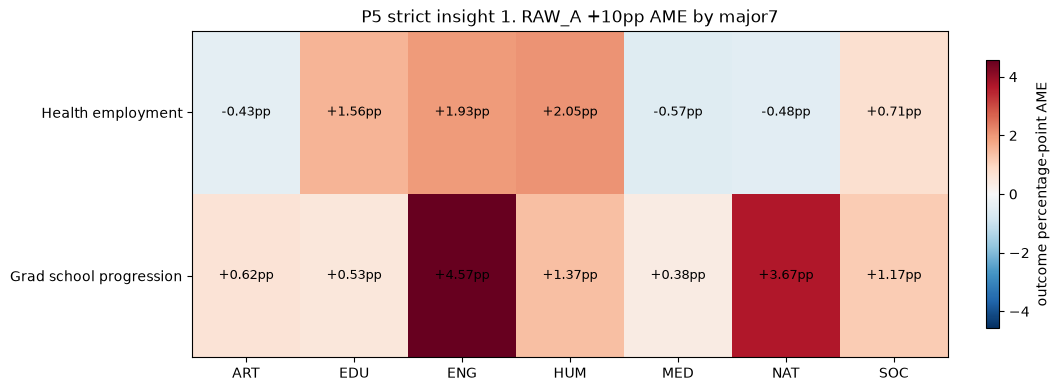

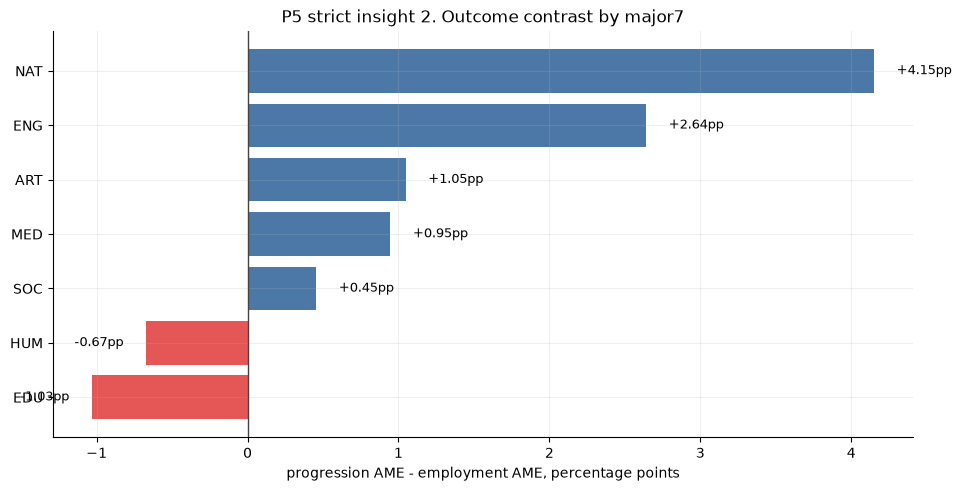

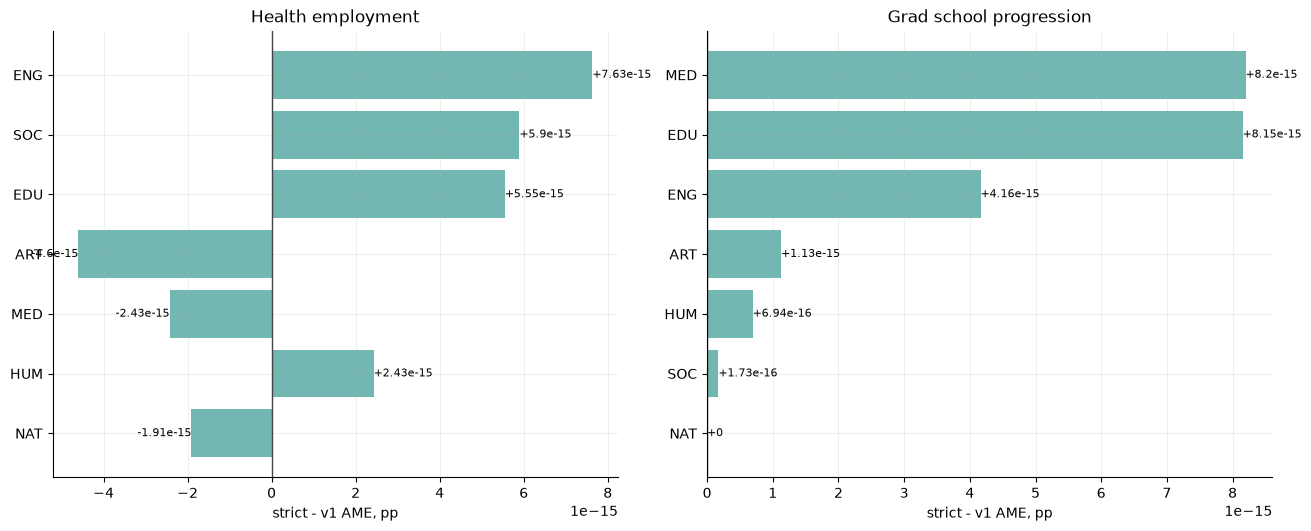

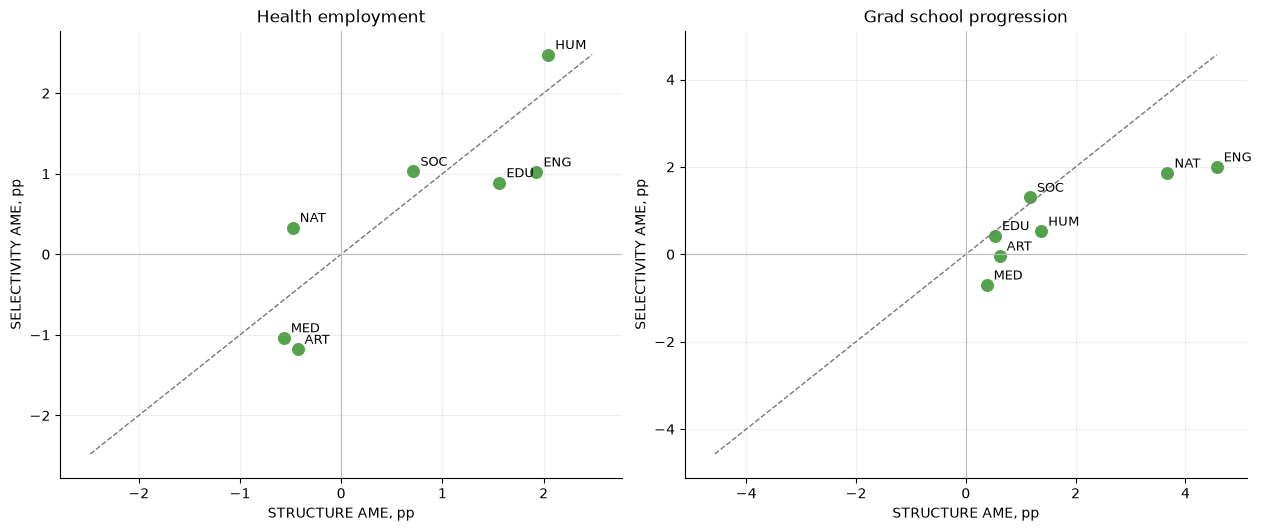

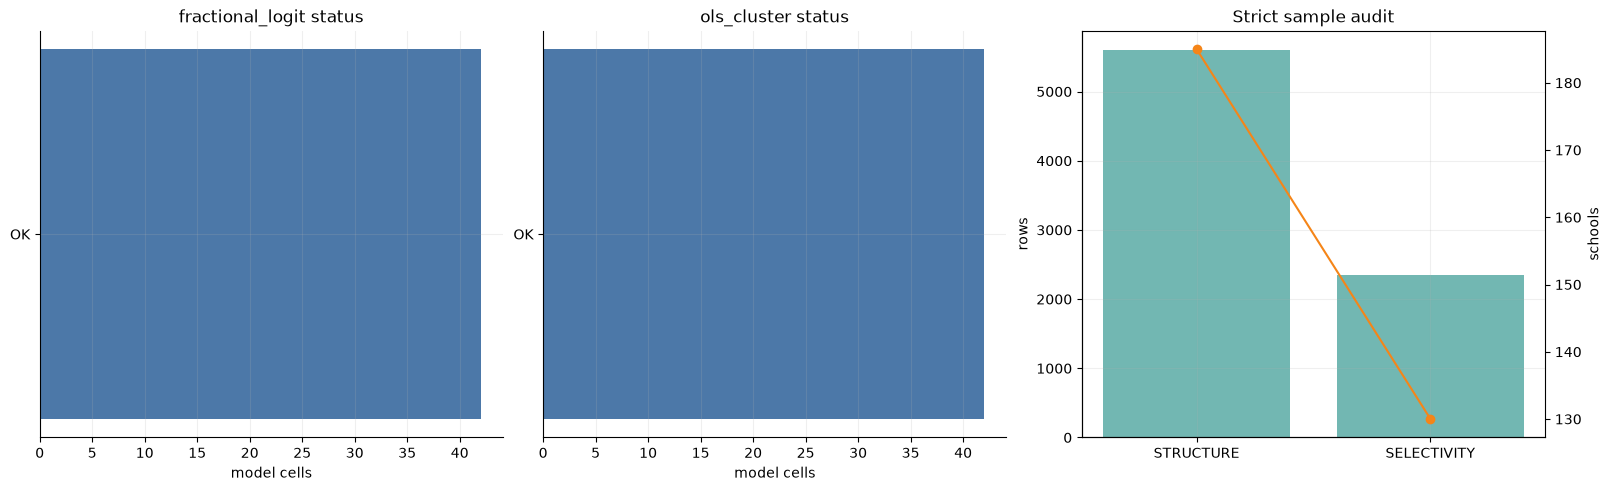

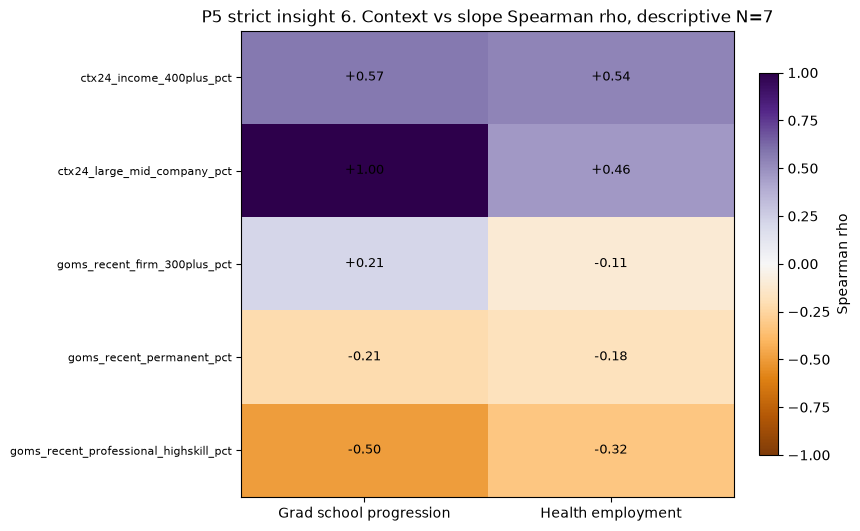

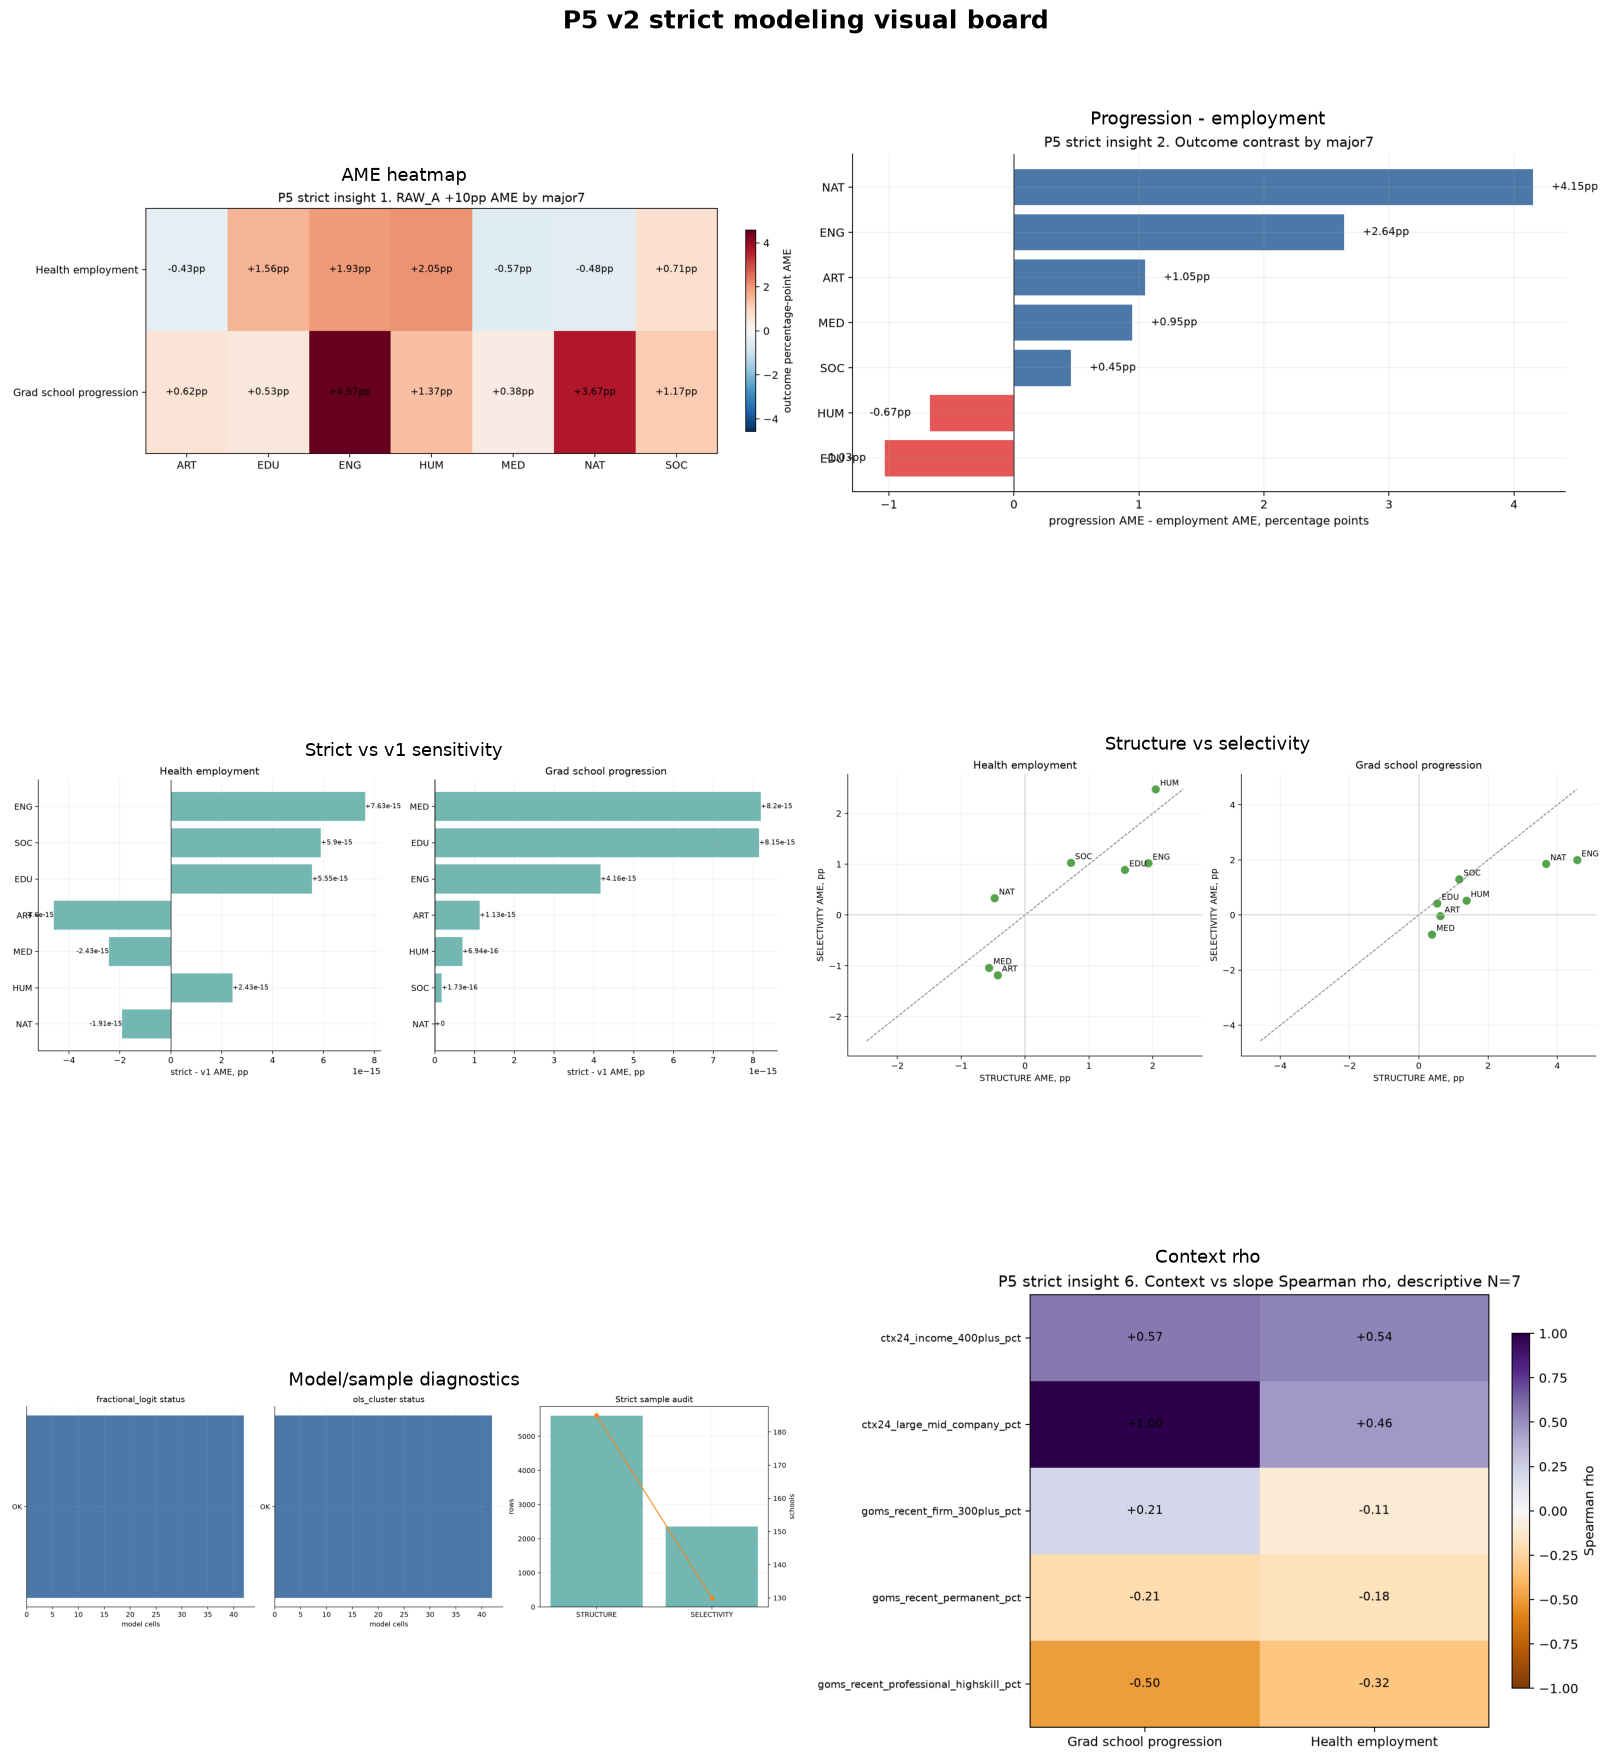

# P5 v2 Strict Modeling Visual Insight Notes

## AME unit
All AME values are outcome percentage-point changes for RAW_A +10 percentage points.

## Key observations
- Grad school progression AME is largest in `ENG`: `+4.57pp`.
- Health employment AME is largest in `HUM`: `+2.05pp`.
- Negative employment AME appears for: `MED`(-0.57pp), `NAT`(-0.48pp), `ART`(-0.43pp).
- Top 3 progression AME: `ENG`(+4.57pp), `NAT`(+3.67pp), `HUM`(+1.37pp).
- Top 3 employment AME: `HUM`(+2.05pp), `ENG`(+1.93pp), `EDU`(+1.56pp).
- Progression-minus-employment contrast is largest in `NAT`: `+4.15pp`.
- The strongest employment-leaning contrast is `EDU`: `-1.03pp`.
- Structure-selectivity sign disagreement appears in: `ART`/GRAD_SCHOOL_PROGRESSION, `MED`/GRAD_SCHOOL_PROGRESSION, `NAT`/HEALTH_EMPLOYMENT.
- Strict-vs-v1 primary structure sensitivity has max absolute AME change `8.2e-15pp`, sign-change cells `0`, and CI-overlap cells `14/14`.

## 발견한 모델링 패턴

1. `RAW_A`는 strict 모델에서 진학률과 취업률에 같은 방식으로 작동하지 않는다. ENG/NAT는 진학률 쪽 AME가 특히 크고, HUM/ENG/EDU는 취업률 쪽 AME가 크다.
2. `MED`, `NAT`, `ART`의 취업률 AME는 음수지만 CI가 0을 가로지르므로 방향을 강하게 단정하지 않는다.
3. `NAT`는 진학 AME와 취업 AME의 차이가 가장 커서, grade signal이 취업보다 진학 쪽 outcome과 더 크게 연결되는 계열로 읽힌다.
4. strict-vs-v1 민감도에서 부호 변화가 0이고 모든 CI가 overlap하므로, strict-clean 계약 적용이 주요 계열별 순위를 뒤집지 않았다.

## Interpretation scaffold

**관찰:** strict-clean 기준에서도 ENG/NAT는 대학원 진학 AME가 크고, HUM/ENG/EDU는 취업 AME가 양의 방향으로 크다.

**원인:** 이 보드는 같은 strict 입력 계약, 같은 primary STRUCTURE/B_CORE 모형, 같은 RAW_A +10pp 단위로 outcome별 조건부 slope를 비교한다.

**제한:** fractional logit AME는 관측 데이터의 조건부 관계를 요약한다. 개인 단위 인과효과, 대학/학과 성과 단정, context 효과 검정으로 해석하지 않는다.

**결론:** strict-clean 재실행 후 v1 대비 부호 변화가 없고 CI가 모두 overlap하므로, 현재 인사이트의 핵심은 strict 계약 아래에서도 계열별 방향 차이가 유지된다는 점이다.

## Interpretation guardrails
- This is a major7-level conditional slope comparison, not a causal effect estimate.
- Context rho is descriptive only because it uses seven major-level points.
- RAW_A is the only strict signal branch; WITHIN_MAJOR_A is intentionally removed as a slope-duplicate branch in this strict notebook.

strict insight outputs
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/artifacts/P5_STRICT_INSIGHT_SUMMARY.csv
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/artifacts/P5_STRICT_INSIGHT_V1_SENSITIVITY_PRIMARY.csv
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/reports/P5_STRICT_MODELING_VISUAL_INSIGHT_NOTES.md
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/figures/P5_STRICT_MODELING_VISUAL_BOARD.png
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/figures/P5_STRICT_INSIGHT_AME_HEATMAP_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/figures/P5_STRICT_INSIGHT_PROGRESSION_MINUS_EMPLOYMENT_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/figures/P5_STRICT_INSIGHT_V1_SENSITIVITY_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/figures/P5_STRICT_INSIGHT_STRUCTURE_SELECTIVITY_STABILITY_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/figures/P5_STRICT_INSIGHT_MODEL_DIAGNOSTIC_DASHBOARD.png
workbook/p2/p2_5/p5_major7_heterogeneit

In [11]:
# 셀 11 목적: m13 시각화 스킬 방식의 모델링 인사이트 보드를 만든다.
# 입력: strict slope, AME difference, v1 sensitivity, stability, diagnostics, context rho.
# 처리: AME heatmap, outcome contrast, strict-vs-v1, branch stability, diagnostic, context rho, 통합 visual board를 생성한다.
# 출력: P5_STRICT_MODELING_VISUAL_BOARD.png, P5_STRICT_INSIGHT_*.png, P5_STRICT_MODELING_VISUAL_INSIGHT_NOTES.md.
# 해석 포인트: 장식용 plot이 아니라 "어떤 계열에서 어떤 outcome slope가 큰가"와 "strict에서도 유지되는가"를 답한다.

from IPython.display import Markdown

OUTCOME_LABELS = {
    "HEALTH_EMPLOYMENT": "Health employment",
    "GRAD_SCHOOL_PROGRESSION": "Grad school progression",
}

def clean_axis(ax):
    ax.grid(alpha=0.20)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

strict_primary = structure_primary.query(
    "model_family == 'fractional_logit' and branch == 'STRUCTURE' and control_set == 'B_CORE'"
).copy()
strict_primary["ame_pp"] = strict_primary["ame_10pp"] * 100
strict_primary["ame_ci_low_pp"] = strict_primary["ame_ci_low_10pp"] * 100
strict_primary["ame_ci_high_pp"] = strict_primary["ame_ci_high_10pp"] * 100
strict_primary["ci_crosses_zero"] = (
    strict_primary["ame_ci_low_10pp"].le(0) & strict_primary["ame_ci_high_10pp"].ge(0)
)
strict_primary["outcome_label"] = strict_primary["outcome"].map(OUTCOME_LABELS).fillna(strict_primary["outcome"])

strict_insight_summary = strict_primary[
    [
        "major_group_7",
        "outcome",
        "outcome_label",
        "grade_signal",
        "ame_10pp",
        "ame_pp",
        "ame_ci_low_10pp",
        "ame_ci_high_10pp",
        "ame_ci_low_pp",
        "ame_ci_high_pp",
        "ci_crosses_zero",
        "row_n",
        "school_n",
        "status",
        "converged",
    ]
].sort_values(["outcome", "ame_10pp"]).reset_index(drop=True)
strict_insight_summary.to_csv(ARTIFACTS_DIR / "P5_STRICT_INSIGHT_SUMMARY.csv", index=False)

# 1) strict AME heatmap.
heat_df = strict_insight_summary.pivot_table(
    index="outcome_label",
    columns="major_group_7",
    values="ame_pp",
    aggfunc="first",
)
heat_df = heat_df.reindex([OUTCOME_LABELS["HEALTH_EMPLOYMENT"], OUTCOME_LABELS["GRAD_SCHOOL_PROGRESSION"]])
heat_values = heat_df.to_numpy(dtype=float)
vmax = np.nanmax(np.abs(heat_values)) if np.isfinite(heat_values).any() else 1.0
vmax = max(vmax, 0.1)
fig, ax = plt.subplots(figsize=(10.5, 3.8), constrained_layout=True)
im = ax.imshow(heat_values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns)
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title("P5 strict insight 1. RAW_A +10pp AME by major7")
for i in range(heat_values.shape[0]):
    for j in range(heat_values.shape[1]):
        value = heat_values[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:+.2f}pp", ha="center", va="center", fontsize=9)
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("outcome percentage-point AME")
strict_heatmap_path = FIGURES_DIR / "P5_STRICT_INSIGHT_AME_HEATMAP_RAW_A.png"
fig.savefig(strict_heatmap_path, dpi=180)
plt.show()
plt.close(fig)

# 2) progression minus employment.
trade_df = df_ame_difference.copy()
trade_df["difference_pp"] = trade_df["difference"] * 100
trade_df = trade_df.sort_values("difference_pp")
fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
colors = np.where(trade_df["difference_pp"] >= 0, "#4C78A8", "#E45756")
ax.barh(trade_df["major_group_7"], trade_df["difference_pp"], color=colors)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_xlabel("progression AME - employment AME, percentage points")
ax.set_title("P5 strict insight 2. Outcome contrast by major7")
clean_axis(ax)
for y, value in enumerate(trade_df["difference_pp"]):
    ha = "left" if value >= 0 else "right"
    x = value + (0.15 if value >= 0 else -0.15)
    ax.text(x, y, f"{value:+.2f}pp", va="center", ha=ha, fontsize=9)
strict_tradeoff_path = FIGURES_DIR / "P5_STRICT_INSIGHT_PROGRESSION_MINUS_EMPLOYMENT_RAW_A.png"
fig.savefig(strict_tradeoff_path, dpi=180)
plt.show()
plt.close(fig)

# 3) v1 vs strict sensitivity. Use percentage points for readability.
sensitivity_primary = df_v1_vs_strict.query(
    "model_family == 'fractional_logit' and branch == 'STRUCTURE' and control_set == 'B_CORE'"
).copy()
sensitivity_primary["old_pp"] = sensitivity_primary["old_ame_10pp"] * 100
sensitivity_primary["strict_pp"] = sensitivity_primary["strict_ame_10pp"] * 100
sensitivity_primary["change_pp"] = (sensitivity_primary["strict_ame_10pp"] - sensitivity_primary["old_ame_10pp"]) * 100
sensitivity_primary["abs_change_pp"] = sensitivity_primary["change_pp"].abs()
sensitivity_primary = sensitivity_primary.sort_values(["outcome", "abs_change_pp"], ascending=[True, False])
sensitivity_primary.to_csv(ARTIFACTS_DIR / "P5_STRICT_INSIGHT_V1_SENSITIVITY_PRIMARY.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
for ax, outcome in zip(axes, ["HEALTH_EMPLOYMENT", "GRAD_SCHOOL_PROGRESSION"]):
    sub = sensitivity_primary.query("outcome == @outcome").sort_values("abs_change_pp")
    ax.barh(sub["major_group_7"], sub["change_pp"], color="#72B7B2")
    ax.axvline(0, color="#444444", linewidth=1)
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome))
    ax.set_xlabel("strict - v1 AME, pp")
    clean_axis(ax)
    for y, value in enumerate(sub["change_pp"]):
        ax.text(value, y, f"{value:+.3g}", va="center", ha="left" if value >= 0 else "right", fontsize=8)
strict_sensitivity_path = FIGURES_DIR / "P5_STRICT_INSIGHT_V1_SENSITIVITY_RAW_A.png"
fig.savefig(strict_sensitivity_path, dpi=180)
plt.show()
plt.close(fig)

# 4) structure vs selectivity stability.
stability_plot = df_structure_selectivity_stability.copy()
stability_plot["structure_pp"] = stability_plot["structure_ame"] * 100
stability_plot["selectivity_pp"] = stability_plot["selectivity_ame"] * 100
outcomes = ["HEALTH_EMPLOYMENT", "GRAD_SCHOOL_PROGRESSION"]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), constrained_layout=True)
for ax, outcome in zip(axes, outcomes):
    sub = stability_plot.query("outcome == @outcome").copy()
    lim = np.nanmax(np.abs(sub[["structure_pp", "selectivity_pp"]].to_numpy(dtype=float)))
    lim = max(lim, 0.5)
    ax.scatter(sub["structure_pp"], sub["selectivity_pp"], s=70, color="#54A24B")
    for _, point in sub.iterrows():
        ax.annotate(str(point["major_group_7"]), (point["structure_pp"], point["selectivity_pp"]), textcoords="offset points", xytext=(5, 4), fontsize=9)
    ax.plot([-lim, lim], [-lim, lim], color="#777777", linewidth=1, linestyle="--")
    ax.axhline(0, color="#BBBBBB", linewidth=0.8)
    ax.axvline(0, color="#BBBBBB", linewidth=0.8)
    ax.set_xlim(-lim * 1.12, lim * 1.12)
    ax.set_ylim(-lim * 1.12, lim * 1.12)
    ax.set_xlabel("STRUCTURE AME, pp")
    ax.set_ylabel("SELECTIVITY AME, pp")
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome))
    clean_axis(ax)
strict_stability_path = FIGURES_DIR / "P5_STRICT_INSIGHT_STRUCTURE_SELECTIVITY_STABILITY_RAW_A.png"
fig.savefig(strict_stability_path, dpi=180)
plt.show()
plt.close(fig)

# 5) strict sample audit and model status.
status_counts = df_slope_estimates.groupby(["model_family", "status"]).size().rename("model_count").reset_index()
sample_plot = pd.DataFrame([structure_audit, selectivity_audit]).copy()
sample_plot["short_sample"] = sample_plot["sample_id"].str.replace("P4_JOINT_", "", regex=False).str.replace("_READY", "", regex=False)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (family, sub) in zip(axes[:2], status_counts.groupby("model_family")):
    sub = sub.sort_values("model_count")
    ax.barh(sub["status"], sub["model_count"], color="#4C78A8")
    ax.set_title(f"{family} status")
    ax.set_xlabel("model cells")
    clean_axis(ax)
ax = axes[2]
ax.bar(sample_plot["short_sample"], sample_plot["row_n"], color="#72B7B2", label="rows")
ax2 = ax.twinx()
ax2.plot(sample_plot["short_sample"], sample_plot["school_n"], color="#F58518", marker="o", label="schools")
ax.set_title("Strict sample audit")
ax.set_ylabel("rows")
ax2.set_ylabel("schools")
clean_axis(ax)
strict_diagnostic_path = FIGURES_DIR / "P5_STRICT_INSIGHT_MODEL_DIAGNOSTIC_DASHBOARD.png"
fig.savefig(strict_diagnostic_path, dpi=180)
plt.show()
plt.close(fig)

# 6) context rho heatmap, descriptive only.
context_rho = df_slope_context_desc.copy()
context_rho["outcome_label"] = context_rho["outcome"].map(OUTCOME_LABELS).fillna(context_rho["outcome"])
rho_heat = context_rho.pivot_table(index="context_column", columns="outcome_label", values="spearman_rho", aggfunc="first")
if not rho_heat.empty:
    values = rho_heat.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(8.5, 5.2), constrained_layout=True)
    im = ax.imshow(values, cmap="PuOr", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(rho_heat.columns)))
    ax.set_xticklabels(rho_heat.columns)
    ax.set_yticks(np.arange(len(rho_heat.index)))
    ax.set_yticklabels(rho_heat.index, fontsize=8)
    ax.set_title("P5 strict insight 6. Context vs slope Spearman rho, descriptive N=7")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = values[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=9)
    cbar = fig.colorbar(im, ax=ax, shrink=0.82)
    cbar.set_label("Spearman rho")
    strict_context_rho_path = FIGURES_DIR / "P5_STRICT_INSIGHT_CONTEXT_RHO_HEATMAP_RAW_A.png"
    fig.savefig(strict_context_rho_path, dpi=180)
    plt.show()
    plt.close(fig)
else:
    strict_context_rho_path = None

import matplotlib.image as mpimg

board_items = [
    ("AME heatmap", strict_heatmap_path),
    ("Progression - employment", strict_tradeoff_path),
    ("Strict vs v1 sensitivity", strict_sensitivity_path),
    ("Structure vs selectivity", strict_stability_path),
    ("Model/sample diagnostics", strict_diagnostic_path),
]
if strict_context_rho_path is not None:
    board_items.append(("Context rho", strict_context_rho_path))

fig, axes = plt.subplots(3, 2, figsize=(16, 18), constrained_layout=True)
axes = axes.ravel()
for ax, (title, path) in zip(axes, board_items):
    ax.imshow(mpimg.imread(path))
    ax.set_title(title, fontsize=13)
    ax.axis("off")
for ax in axes[len(board_items):]:
    ax.axis("off")
fig.suptitle("P5 v2 strict modeling visual board", fontsize=18, fontweight="bold")
strict_visual_board_path = FIGURES_DIR / "P5_STRICT_MODELING_VISUAL_BOARD.png"
fig.savefig(strict_visual_board_path, dpi=180)
plt.show()
plt.close(fig)

top_progression = strict_insight_summary.query("outcome == 'GRAD_SCHOOL_PROGRESSION'").sort_values("ame_pp", ascending=False).head(1)
top_employment = strict_insight_summary.query("outcome == 'HEALTH_EMPLOYMENT'").sort_values("ame_pp", ascending=False).head(1)
negative_employment = strict_insight_summary.query("outcome == 'HEALTH_EMPLOYMENT' and ame_pp < 0").sort_values("ame_pp")
top_tradeoff = trade_df.sort_values("difference_pp", ascending=False).head(1)
bottom_tradeoff = trade_df.sort_values("difference_pp").head(1)
max_sensitivity_pp = float(sensitivity_primary["abs_change_pp"].max()) if len(sensitivity_primary) else np.nan
sign_change_n = int(sensitivity_primary["sign_change"].fillna(False).sum()) if len(sensitivity_primary) else 0
ci_overlap_n = int(sensitivity_primary["ci_overlap"].fillna(False).sum()) if len(sensitivity_primary) else 0

strict_insight_lines = [
    "# P5 v2 Strict Modeling Visual Insight Notes",
    "",
    "## AME unit",
    "All AME values are outcome percentage-point changes for RAW_A +10 percentage points.",
    "",
    "## Key observations",
]
if len(top_progression):
    row = top_progression.iloc[0]
    strict_insight_lines.append(f"- Grad school progression AME is largest in `{row['major_group_7']}`: `{row['ame_pp']:+.2f}pp`.")
if len(top_employment):
    row = top_employment.iloc[0]
    strict_insight_lines.append(f"- Health employment AME is largest in `{row['major_group_7']}`: `{row['ame_pp']:+.2f}pp`.")
if len(negative_employment):
    pairs = ", ".join(f"`{r.major_group_7}`({r.ame_pp:+.2f}pp)" for r in negative_employment.itertuples())
    strict_insight_lines.append(f"- Negative employment AME appears for: {pairs}.")
top_progression_3 = strict_insight_summary.query("outcome == 'GRAD_SCHOOL_PROGRESSION'").sort_values("ame_pp", ascending=False).head(3)
top_employment_3 = strict_insight_summary.query("outcome == 'HEALTH_EMPLOYMENT'").sort_values("ame_pp", ascending=False).head(3)
if len(top_progression_3):
    pairs = ", ".join(f"`{r.major_group_7}`({r.ame_pp:+.2f}pp)" for r in top_progression_3.itertuples())
    strict_insight_lines.append(f"- Top 3 progression AME: {pairs}.")
if len(top_employment_3):
    pairs = ", ".join(f"`{r.major_group_7}`({r.ame_pp:+.2f}pp)" for r in top_employment_3.itertuples())
    strict_insight_lines.append(f"- Top 3 employment AME: {pairs}.")
if len(top_tradeoff):
    row = top_tradeoff.iloc[0]
    strict_insight_lines.append(f"- Progression-minus-employment contrast is largest in `{row['major_group_7']}`: `{row['difference_pp']:+.2f}pp`.")
if len(bottom_tradeoff):
    row = bottom_tradeoff.iloc[0]
    strict_insight_lines.append(f"- The strongest employment-leaning contrast is `{row['major_group_7']}`: `{row['difference_pp']:+.2f}pp`.")
sign_breaks = stability_plot.loc[~stability_plot["sign_agreement"].fillna(False)].copy()
if len(sign_breaks):
    pairs = ", ".join(f"`{r.major_group_7}`/{r.outcome}" for r in sign_breaks.itertuples())
    strict_insight_lines.append(f"- Structure-selectivity sign disagreement appears in: {pairs}.")
else:
    strict_insight_lines.append("- Structure-selectivity sign direction agrees in every compared cell.")
strict_insight_lines.extend(
    [
        f"- Strict-vs-v1 primary structure sensitivity has max absolute AME change `{max_sensitivity_pp:.3g}pp`, sign-change cells `{sign_change_n}`, and CI-overlap cells `{ci_overlap_n}/{len(sensitivity_primary)}`.",
        "",
        "## 발견한 모델링 패턴",
        "",
        "1. `RAW_A`는 strict 모델에서 진학률과 취업률에 같은 방식으로 작동하지 않는다. ENG/NAT는 진학률 쪽 AME가 특히 크고, HUM/ENG/EDU는 취업률 쪽 AME가 크다.",
        "2. `MED`, `NAT`, `ART`의 취업률 AME는 음수지만 CI가 0을 가로지르므로 방향을 강하게 단정하지 않는다.",
        "3. `NAT`는 진학 AME와 취업 AME의 차이가 가장 커서, grade signal이 취업보다 진학 쪽 outcome과 더 크게 연결되는 계열로 읽힌다.",
        "4. strict-vs-v1 민감도에서 부호 변화가 0이고 모든 CI가 overlap하므로, strict-clean 계약 적용이 주요 계열별 순위를 뒤집지 않았다.",
        "",
        "## Interpretation scaffold",
        "",
        "**관찰:** strict-clean 기준에서도 ENG/NAT는 대학원 진학 AME가 크고, HUM/ENG/EDU는 취업 AME가 양의 방향으로 크다.",
        "",
        "**원인:** 이 보드는 같은 strict 입력 계약, 같은 primary STRUCTURE/B_CORE 모형, 같은 RAW_A +10pp 단위로 outcome별 조건부 slope를 비교한다.",
        "",
        "**제한:** fractional logit AME는 관측 데이터의 조건부 관계를 요약한다. 개인 단위 인과효과, 대학/학과 성과 단정, context 효과 검정으로 해석하지 않는다.",
        "",
        "**결론:** strict-clean 재실행 후 v1 대비 부호 변화가 없고 CI가 모두 overlap하므로, 현재 인사이트의 핵심은 strict 계약 아래에서도 계열별 방향 차이가 유지된다는 점이다.",
        "",
        "## Interpretation guardrails",
        "- This is a major7-level conditional slope comparison, not a causal effect estimate.",
        "- Context rho is descriptive only because it uses seven major-level points.",
        "- RAW_A is the only strict signal branch; WITHIN_MAJOR_A is intentionally removed as a slope-duplicate branch in this strict notebook.",
    ]
)
strict_insight_note_path = REPORTS_DIR / "P5_STRICT_MODELING_VISUAL_INSIGHT_NOTES.md"
strict_insight_note_path.write_text("\n".join(strict_insight_lines), encoding="utf-8")
display(Markdown("\n".join(strict_insight_lines)))

strict_insight_outputs = [
    ARTIFACTS_DIR / "P5_STRICT_INSIGHT_SUMMARY.csv",
    ARTIFACTS_DIR / "P5_STRICT_INSIGHT_V1_SENSITIVITY_PRIMARY.csv",
    REPORTS_DIR / "P5_STRICT_MODELING_VISUAL_INSIGHT_NOTES.md",
    strict_visual_board_path,
    strict_heatmap_path,
    strict_tradeoff_path,
    strict_sensitivity_path,
    strict_stability_path,
    strict_diagnostic_path,
]
if strict_context_rho_path is not None:
    strict_insight_outputs.append(strict_context_rho_path)

print("strict insight outputs")
for path in strict_insight_outputs:
    print(rel(path))

In [12]:
# 셀 12 목적: 최종 리포트, 상태 JSON, manifest를 저장한다.
# 입력: 앞 셀에서 생성한 모든 QA/artifact/figure/report.
# 처리: markdown report, strict status payload, output manifest와 lineage hash를 작성한다.
# 출력: P5_2024_MAJOR7_HETEROGENEITY_V2_STRICT_REPORT.md, STATUS.json, P5_OUTPUT_MANIFEST.json.
# 해석 포인트: notebook 실행 성공뿐 아니라 어떤 파일이 어떤 hash로 남았는지 재현성 계약을 닫는 셀이다.

def markdown_table(df: pd.DataFrame) -> str:
    if df.empty:
        return "_empty_"
    out = df.copy().astype(object).where(pd.notna(df), "")
    cols = [str(c) for c in out.columns]
    lines = ["| " + " | ".join(cols) + " |", "| " + " | ".join(["---"] * len(cols)) + " |"]
    for _, row in out.iterrows():
        lines.append("| " + " | ".join(str(row[c]).replace("|", "/") for c in out.columns) + " |")
    return "\n".join(lines)

report_lines = [
    "# P5 v2 Strict Major7 Heterogeneity Report",
    "",
    "## 1. 연구질문",
    "같은 전공계열 안에서 학과별 A비율과 건강보험 취업률·대학원 진학률의 조건부 기울기가 어떻게 다른지 탐색했다.",
    "",
    "## 2. strict-clean 입력 계약",
    f"- strict D08: `{rel(INPUTS['strict_d08'])}`",
    f"- strict D08 shape: `{file_shape(INPUTS['strict_d08'])}`",
    f"- strict D08 SHA256: `{sha256_file(INPUTS['strict_d08'])}`",
    f"- structure joint sample: N={len(df_p5_structure):,}, school_n={df_p5_structure['school_uid'].nunique():,}",
    f"- selectivity joint sample: N={len(df_p5_selectivity):,}, school_n={df_p5_selectivity['school_uid'].nunique():,}",
    "",
    "## 3. Grade Signal",
    "`RAW_A = a_rate_pct / 10`만 계열별 slope 모형에 사용했다. `WITHIN_MAJOR_A`는 같은 계열 안에서 RAW_A에 계열별 상수를 뺀 값이므로, 절편 포함 계열별 회귀에서는 slope가 RAW_A와 동일하다. 따라서 v2 strict 계열별 모형에서는 중복 branch를 제거했다.",
    "",
    "## 4. cell eligibility",
    markdown_table(df_cell_eligibility.groupby(['branch', 'outcome', 'grade_signal'])['estimable'].sum().reset_index(name='estimable_major_count')),
    "",
    "## 5. 건강보험 취업 기울기",
    markdown_table(table1[['major_group_7', 'ame_10pp', 'ame_ci_low_10pp', 'ame_ci_high_10pp', 'row_n', 'school_n']]),
    "",
    "## 6. 대학원 진학 기울기",
    markdown_table(table2[['major_group_7', 'ame_10pp', 'ame_ci_low_10pp', 'ame_ci_high_10pp', 'row_n', 'school_n']]),
    "",
    "## 7. 취업·진학 차이",
    markdown_table(df_ame_difference[['major_group_7', 'employment_ame', 'progression_ame', 'difference']]),
    "",
    "## 8. structure vs selectivity 안정성",
    markdown_table(df_structure_selectivity_stability[['major_group_7', 'outcome', 'structure_ame', 'selectivity_ame', 'sign_agreement', 'ci_overlap']]),
    "",
    "## 9. context 기술 비교",
    "Context profile primary table은 유효한 7개 major만 포함한다. Spearman rho는 N=7 기술통계이며 context 효과 검정으로 해석하지 않는다.",
    "",
    "## 10. 한계와 금지해석",
    "- Fractional logit은 fractional response quasi-likelihood로 사용했다.",
    "- 개인 단위 Bernoulli likelihood 또는 인과효과로 해석하지 않는다.",
    "- context가 slope를 증가시켰다는 확증적 표현을 금지한다.",
    "",
    "## 11. P3 residual 상태",
    f"`P5_RESIDUAL_STATUS = {P5_RESIDUAL_STATUS}`",
    "",
    "## 12. v1 vs strict 비교",
    f"`P5_V1_COMPARISON_STATUS = {P5_V1_COMPARISON_STATUS}`. 비교표는 `artifacts/P5_V1_VS_STRICT_SENSITIVITY.csv`에 저장했다.",
    "",
]
report_path = REPORTS_DIR / "P5_2024_MAJOR7_HETEROGENEITY_V2_STRICT_REPORT.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

P5_OVERALL_STATUS = "READY_WITH_WARNINGS" if P5_RESIDUAL_STATUS.startswith("PENDING") else "READY"
if len(df_model_failures):
    P5_OVERALL_STATUS = "READY_WITH_WARNINGS"

status_payload = {
    **EXECUTION_CONTEXT,
    "P5_STRICT_INPUT_STATUS": P5_STRICT_INPUT_STATUS,
    "P5_STRICT_STRUCTURE_STATUS": P5_STRICT_STRUCTURE_STATUS,
    "P5_STRICT_SELECTIVITY_STATUS": P5_STRICT_SELECTIVITY_STATUS,
    "P5_RAW_A_STATUS": P5_RAW_A_STATUS,
    "P5_RESIDUAL_STATUS": P5_RESIDUAL_STATUS,
    "P5_CONTEXT_STATUS": P5_CONTEXT_STATUS,
    "P5_V1_COMPARISON_STATUS": P5_V1_COMPARISON_STATUS,
    "P5_OVERALL_STATUS": P5_OVERALL_STATUS,
    "strict_d08_path": rel(INPUTS["strict_d08"]),
    "strict_d08_shape": file_shape(INPUTS["strict_d08"]),
    "strict_d08_sha256": sha256_file(INPUTS["strict_d08"]),
    "structure_sample": structure_audit,
    "selectivity_sample": selectivity_audit,
    "slope_rows": int(len(df_slope_estimates)),
    "model_failures": int(len(df_model_failures)),
}
status_path = REPORTS_DIR / "P5_2024_MAJOR7_HETEROGENEITY_V2_STRICT_STATUS.json"
status_path.write_text(json.dumps(status_payload, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

def artifact_record(path: Path) -> dict:
    shape = None
    if path.suffix == ".csv":
        try:
            shape = tuple(pd.read_csv(path).shape)
        except Exception:
            shape = None
    elif path.suffix == ".parquet":
        try:
            shape = tuple(pd.read_parquet(path).shape)
        except Exception:
            shape = None
    stat = path.stat()
    return {
        "path": rel(path),
        "shape": shape,
        "size_bytes": int(stat.st_size),
        "sha256": sha256_file(path),
        "mtime": datetime.fromtimestamp(stat.st_mtime).isoformat(),
    }

manifest_paths = sorted([p for p in OUTPUT_ROOT.rglob("*") if p.is_file() and p.name != "P5_OUTPUT_MANIFEST.json"])
external_lineage_paths = [
    INPUTS["strict_d08"],
    INPUTS["phase_sample_registry"],
    INPUTS["phase_sample_membership"],
    INPUTS["manual_feature_registry"],
    INPUTS["target_denylist"],
]
manifest_payload = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "output_root": str(OUTPUT_ROOT),
    "notebook_path": str(NOTEBOOK_PATH),
    "lineage_inputs": [artifact_record(p) for p in external_lineage_paths],
    "outputs": [artifact_record(p) for p in manifest_paths],
    "required_hashes": {
        "strict_d08_sha256": sha256_file(INPUTS["strict_d08"]),
        "sample_registry_sha256": sha256_file(INPUTS["phase_sample_registry"]),
        "structure_frame_sha256": sha256_file(DATA_DIR / "P5_STRUCTURE_ANALYSIS_FRAME.parquet"),
        "selectivity_frame_sha256": sha256_file(DATA_DIR / "P5_SELECTIVITY_ANALYSIS_FRAME.parquet"),
        "result_table_sha256": sha256_file(ARTIFACTS_DIR / "P5_MAJOR7_SLOPE_ESTIMATES.csv"),
        "notebook_sha256": sha256_file(NOTEBOOK_PATH) if NOTEBOOK_PATH.exists() else None,
    },
}
manifest_path = LOGS_DIR / "P5_OUTPUT_MANIFEST.json"
manifest_path.write_text(json.dumps(manifest_payload, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

display(pd.DataFrame([status_payload]))
print("report:", rel(report_path))
print("manifest:", rel(manifest_path))

,python,platform,pandas,numpy,statsmodels,working_directory,git_commit,execution_timestamp_utc,notebook_path,output_root,...,P5_CONTEXT_STATUS,P5_V1_COMPARISON_STATUS,P5_OVERALL_STATUS,strict_d08_path,strict_d08_shape,strict_d08_sha256,structure_sample,selectivity_sample,slope_rows,model_failures
0,3.12.3,Linux-6.18.33.2-microsoft-standard-WSL2-x86_64...,3.0.3,2.5.0,0.14.6,/home/sieg/projects-wsl/SBS_dataScience,5b1a3d54266d881a839ad9a3cec750da66e94bc7,2026-07-13T06:09:50.971201+00:00,/home/sieg/projects-wsl/SBS_dataScience/workbo...,/home/sieg/projects-wsl/SBS_dataScience/workbo...,...,READY,READY,READY_WITH_WARNINGS,workbook/p2/p2_4/source_eda/strict_clean_v1/ma...,"(7592, 151)",5f56e375fd1c0474a5e55652859ae007e2f45becd6d335...,"{'sample_id': 'P4_JOINT_STRUCTURE_READY', 'row...","{'sample_id': 'P4_JOINT_SELECTIVITY_READY', 'r...",84,0


report: workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/reports/P5_2024_MAJOR7_HETEROGENEITY_V2_STRICT_REPORT.md
manifest: workbook/p2/p2_5/p5_major7_heterogeneity_v2_strict/logs/P5_OUTPUT_MANIFEST.json
